# API Evolution and Breaking-Change Use Cases Across Libraries

The notebook focuses on four questions:

- How do public APIs typically evolve over the lifetime of a library?
- When in a library's history are breaking changes most often introduced?
- How strongly are public-API breaking changes associated with updating, creating, or deleting Java source files?
- How much of the detected breakage falls on public API symbols versus excluded or internal symbols?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("data")
CHANGE_BUCKET_ORDER = [
    "No Java file changes",
    "Updates existing Java files only",
    "Creates Java files without deletions",
    "Includes Java deletions",
]
BOOL_COLS_COMMITS = ["is_merge_commit", "api_changed", "has_java_changes", "has_pom_changes"]
BOOL_COLS_BCS = ["is_excluded_symbol", "is_deprecated_removal", "is_internal_removal"]
NUMERIC_COLS_COMMITS = [
    "days_since_prev_commit",
    "files_changed",
    "loc_added",
    "loc_deleted",
    "updated_java_files_count",
    "deleted_java_files_count",
    "created_java_files_count",
    "all_api_types_count",
    "all_api_methods_count",
    "all_api_fields_count",
    "all_api_symbols_count",
    "exported_types_count",
    "exported_methods_count",
    "exported_fields_count",
    "exported_symbols_count",
    "deprecated_count",
    "internal_count",
    "all_breaking_changes_count",
    "api_breaking_changes_count",
    "excluded_breaking_changes_count",
    "binary_breaking_changes_count",
    "source_breaking_changes_count",
]

commit_frames = []
for path in sorted(DATA_DIR.glob("*-commits.csv")):
    df = pd.read_csv(path, low_memory=False)
    df["library"] = df["library"].fillna(path.stem.removesuffix("-commits"))
    commit_frames.append(df)

commits_df = pd.concat(commit_frames, ignore_index=True)
commits_df["date_utc"] = pd.to_datetime(commits_df["date_utc"], errors="coerce", utc=True)
for col in BOOL_COLS_COMMITS:
    commits_df[col] = commits_df[col].astype(str).str.lower().eq("true")
for col in NUMERIC_COLS_COMMITS:
    if col not in commits_df.columns:
        commits_df[col] = 0
    commits_df[col] = pd.to_numeric(commits_df[col], errors="coerce").fillna(0)

exported_symbol_fallback = (
    commits_df["exported_types_count"]
    + commits_df["exported_methods_count"]
    + commits_df["exported_fields_count"]
)
commits_df["exported_symbols_count"] = commits_df["exported_symbols_count"].where(
    commits_df["exported_symbols_count"] > 0, exported_symbol_fallback
)
commits_df["breaking_changes_count"] = commits_df["api_breaking_changes_count"]
commits_df["has_breaks"] = commits_df["api_breaking_changes_count"] > 0
commits_df["java_files_touched_count"] = (
    commits_df["updated_java_files_count"]
    + commits_df["deleted_java_files_count"]
    + commits_df["created_java_files_count"]
)
commits_df["change_bucket"] = np.select(
    [
        commits_df["java_files_touched_count"] == 0,
        commits_df["deleted_java_files_count"] > 0,
        commits_df["created_java_files_count"] > 0,
        commits_df["updated_java_files_count"] > 0,
    ],
    [
        "No Java file changes",
        "Includes Java deletions",
        "Creates Java files without deletions",
        "Updates existing Java files only",
    ],
    default="Updates existing Java files only",
)
commits_df["change_bucket"] = pd.Categorical(
    commits_df["change_bucket"],
    categories=CHANGE_BUCKET_ORDER,
    ordered=True,
)
commits_df = commits_df.sort_values(["library", "date_utc", "commit_sha"]).reset_index(drop=True)

bc_frames = []
for path in sorted(DATA_DIR.glob("*-bcs.csv")):
    df = pd.read_csv(path)
    if df.empty:
        continue
    df["library"] = df["library"].fillna(path.stem.removesuffix("-bcs"))
    bc_frames.append(df)

bcs_df = pd.concat(bc_frames, ignore_index=True)
for col in BOOL_COLS_BCS:
    bcs_df[col] = bcs_df[col].astype(str).str.lower().eq("true")

print(f"Libraries: {commits_df['library'].nunique()}")
print(f"Commit rows: {len(commits_df):,}")
print(f"Breaking-change rows: {len(bcs_df):,}")

Libraries: 29
Commit rows: 185,817
Breaking-change rows: 194,600


## Derived Profile Metrics

To compare library histories, the notebook derives a small set of longitudinal indicators:

- **API growth ratio**: final exported API size divided by the first non-zero exported API size.
- **Break commit share**: fraction of commits that introduce at least one breaking change.
- **Break timing**: where breaking changes are located in the history, measured with quartile shares and a break center of mass.
- **Break concentration**: how much of a library's total break volume is concentrated in its top 1% most disruptive commits.
- **Break file-operation mix**: among break commits, the share of updated, deleted, and created Java files, plus the share of break commits that delete at least one Java file.

These indicators make it possible to compare all library histories in the corpus and to distinguish update-driven and removal-driven public-API instability.

In [2]:
profile_rows = []
timeline_frames = []

for lib, d in commits_df.groupby("library", sort=False):
    d = d.sort_values(["date_utc", "commit_sha"]).reset_index(drop=True).copy()
    d["commit_index"] = np.arange(1, len(d) + 1)
    d["history_pct"] = 0.0 if len(d) == 1 else d.index / (len(d) - 1)
    d["history_decile"] = np.minimum((d["history_pct"] * 10).astype(int) + 1, 10)
    peak_exported = float(d["exported_symbols_count"].max())
    d["api_relative_to_peak"] = d["exported_symbols_count"] / peak_exported if peak_exported else 0.0
    timeline_frames.append(d)

    non_zero_api = d.loc[d["exported_symbols_count"] > 0, "exported_symbols_count"]
    first_nonzero_exported = float(non_zero_api.iloc[0]) if not non_zero_api.empty else 0.0
    final_exported = float(d["exported_symbols_count"].iloc[-1])
    total_breaks = float(d["api_breaking_changes_count"].sum())
    total_all_breaks = float(d["all_breaking_changes_count"].sum())
    total_excluded_breaks = float(d["excluded_breaking_changes_count"].sum())
    break_commits_df = d[d["has_breaks"]].copy()
    break_commits = int(len(break_commits_df))
    top_n = max(1, int(np.ceil(len(d) * 0.01)))
    top1pct_break_share = (
        float(d["api_breaking_changes_count"].nlargest(top_n).sum() / total_breaks)
        if total_breaks
        else 0.0
    )
    break_center = (
        float((d["history_pct"] * d["api_breaking_changes_count"]).sum() / total_breaks)
        if total_breaks
        else np.nan
    )
    quarter_indexes = np.array_split(d.index.to_numpy(), 4)
    quarter_shares = []
    for idx in quarter_indexes:
        q_breaks = d.loc[idx, "api_breaking_changes_count"].sum()
        quarter_shares.append(float(q_breaks / total_breaks) if total_breaks else 0.0)

    java_ops_break = break_commits_df[[
        "updated_java_files_count",
        "deleted_java_files_count",
        "created_java_files_count",
    ]].sum()
    break_java_ops_total = float(java_ops_break.sum())
    delete_commits = d[d["deleted_java_files_count"] > 0]
    update_only_commits = d[
        (d["updated_java_files_count"] > 0)
        & (d["deleted_java_files_count"] == 0)
        & (d["created_java_files_count"] == 0)
    ]

    profile_rows.append(
        {
            "library": lib,
            "commits": len(d),
            "years_span": (d["date_utc"].max() - d["date_utc"].min()).days / 365.25,
            "first_commit": d["date_utc"].min(),
            "last_commit": d["date_utc"].max(),
            "first_nonzero_exported": first_nonzero_exported,
            "final_exported": final_exported,
            "peak_exported": peak_exported,
            "growth_ratio": (final_exported / first_nonzero_exported) if first_nonzero_exported else np.nan,
            "net_growth": final_exported - first_nonzero_exported,
            "break_commits": break_commits,
            "break_commit_share": break_commits / len(d),
            "api_change_share": float(d["api_changed"].mean()),
            "total_breaks": total_breaks,
            "total_all_breaks": total_all_breaks,
            "total_excluded_breaks": total_excluded_breaks,
            "excluded_break_share": (total_excluded_breaks / total_all_breaks) if total_all_breaks else np.nan,
            "breaks_per_break_commit": (total_breaks / break_commits) if break_commits else np.nan,
            "breaks_per_1k_final_exported": (total_breaks / final_exported * 1000) if final_exported else np.nan,
            "max_breaks": float(d["api_breaking_changes_count"].max()),
            "top1pct_break_share": top1pct_break_share,
            "break_center": break_center,
            "q1_break_share": quarter_shares[0],
            "q2_break_share": quarter_shares[1],
            "q3_break_share": quarter_shares[2],
            "q4_break_share": quarter_shares[3],
            "deleted_break_commit_share": float((break_commits_df["deleted_java_files_count"] > 0).mean()) if break_commits else np.nan,
            "updated_break_commit_share": float((break_commits_df["updated_java_files_count"] > 0).mean()) if break_commits else np.nan,
            "created_break_commit_share": float((break_commits_df["created_java_files_count"] > 0).mean()) if break_commits else np.nan,
            "updated_java_share_in_break_ops": float(java_ops_break["updated_java_files_count"] / break_java_ops_total) if break_java_ops_total else np.nan,
            "deleted_java_share_in_break_ops": float(java_ops_break["deleted_java_files_count"] / break_java_ops_total) if break_java_ops_total else np.nan,
            "created_java_share_in_break_ops": float(java_ops_break["created_java_files_count"] / break_java_ops_total) if break_java_ops_total else np.nan,
            "break_rate_when_delete": float(delete_commits["has_breaks"].mean()) if len(delete_commits) else np.nan,
            "break_rate_update_only": float(update_only_commits["has_breaks"].mean()) if len(update_only_commits) else np.nan,
        }
    )
timelines_df = pd.concat(timeline_frames, ignore_index=True)
profile_df = pd.DataFrame(profile_rows).sort_values("commits", ascending=False).set_index("library")
profile_df["deletion_premium"] = profile_df["break_rate_when_delete"] - profile_df["break_rate_update_only"]

api_shape = (
    timelines_df.groupby(["library", "history_decile"])["api_relative_to_peak"]
    .mean()
    .unstack(fill_value=0)
)
break_shape = (
    timelines_df.groupby(["library", "history_decile"])["breaking_changes_count"]
    .sum()
    .unstack(fill_value=0)
)
break_shape = break_shape.div(break_shape.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

bucket_summary = (
    commits_df.groupby("change_bucket", observed=False)
    .agg(
        commits=("commit_sha", "size"),
        share_of_commits=("commit_sha", lambda s: len(s) / len(commits_df)),
        break_rate=("has_breaks", "mean"),
        mean_breaks=("breaking_changes_count", "mean"),
        median_breaks=("breaking_changes_count", "median"),
    )
    .reindex(CHANGE_BUCKET_ORDER)
)
break_bucket_share = (
    commits_df[commits_df["has_breaks"]]
    .groupby("change_bucket", observed=False)
    .size()
    .reindex(CHANGE_BUCKET_ORDER, fill_value=0)
)
bucket_summary["share_of_break_commits"] = break_bucket_share / break_bucket_share.sum()

break_commits_with_java = commits_df[
    commits_df["has_breaks"] & (commits_df["java_files_touched_count"] > 0)
].copy()
break_commits_with_java["deletion_share"] = (
    break_commits_with_java["deleted_java_files_count"]
    / break_commits_with_java["java_files_touched_count"]
)
break_commits_with_java["update_share"] = (
    break_commits_with_java["updated_java_files_count"]
    / break_commits_with_java["java_files_touched_count"]
)
update_dominant_break_share = float((break_commits_with_java["update_share"] >= 0.8).mean())
delete_dominant_break_share = float((break_commits_with_java["deletion_share"] >= 0.5).mean())

heatmap_order = profile_df.sort_values(["break_center", "total_breaks"], ascending=[True, False]).index.tolist()
heatmap_labels = heatmap_order

scope_summary = profile_df[[
    "commits",
    "years_span",
    "final_exported",
    "growth_ratio",
    "break_commit_share",
    "api_change_share",
    "total_breaks",
    "total_excluded_breaks",
    "excluded_break_share",
    "deleted_break_commit_share",
    "q1_break_share",
    "q4_break_share",
]].sort_values(["total_breaks", "commits"], ascending=[False, False]).round(3)

public_bcs_df = bcs_df[~bcs_df["is_excluded_symbol"]].copy()
non_public_bcs_df = bcs_df[bcs_df["is_excluded_symbol"]].copy()

kind_scope_rows = []
for scope_name, scope_df in [("Public API", public_bcs_df), ("Excluded/Internal", non_public_bcs_df)]:
    if scope_df.empty:
        continue
    counts = (
        scope_df.groupby(["library", "kind"])
        .size()
        .rename("count")
        .reset_index()
    )
    counts["share"] = counts.groupby("library")["count"].transform(lambda s: s / s.sum())
    counts["scope"] = scope_name
    kind_scope_rows.append(counts)

kind_scope_df = pd.concat(kind_scope_rows, ignore_index=True)
scope_order = profile_df.sort_values(["excluded_break_share", "total_breaks"], ascending=[False, False]).index.tolist()

top_public_kinds = (
    kind_scope_df[kind_scope_df["scope"] == "Public API"]
    .groupby("kind")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)
top_non_public_kinds = (
    kind_scope_df[kind_scope_df["scope"] == "Excluded/Internal"]
    .groupby("kind")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

public_kind_matrix = (
    kind_scope_df[
        (kind_scope_df["scope"] == "Public API")
        & (kind_scope_df["kind"].isin(top_public_kinds))
    ]
    .pivot(index="library", columns="kind", values="share")
    .reindex(scope_order)
    .fillna(0)
)
non_public_kind_matrix = (
    kind_scope_df[
        (kind_scope_df["scope"] == "Excluded/Internal")
        & (kind_scope_df["kind"].isin(top_non_public_kinds))
    ]
    .pivot(index="library", columns="kind", values="share")
    .reindex(scope_order)
    .fillna(0)
)

break_scope_share = profile_df.loc[scope_order, ["total_breaks", "total_excluded_breaks"]].rename(
    columns={"total_breaks": "Public API", "total_excluded_breaks": "Excluded/Internal"}
)
break_scope_share = break_scope_share.div(
    break_scope_share.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0)

selection_plot_df = profile_df.loc[heatmap_order, [
    "total_breaks",
    "q4_break_share",
    "deleted_break_commit_share",
]].reset_index()

## Corpus Overview

In [3]:
overview = profile_df[[
    "commits",
    "years_span",
    "final_exported",
    "growth_ratio",
    "break_commit_share",
    "api_change_share",
    "deleted_break_commit_share",
    "total_breaks",
    "total_excluded_breaks",
    "excluded_break_share",
    "max_breaks",
]].sort_values("commits", ascending=False).round(3)

display(overview)

median_growth = profile_df["growth_ratio"].median()
early_break_libs = int(((profile_df["q1_break_share"] + profile_df["q2_break_share"]) > 0.75).sum())
late_break_libs = profile_df.index[profile_df["q4_break_share"] > 0.5].tolist()
delete_rate = bucket_summary.loc["Includes Java deletions", "break_rate"]
update_only_rate = bucket_summary.loc["Updates existing Java files only", "break_rate"]
median_excluded_share = profile_df["excluded_break_share"].dropna().median()
lines = [
    f"- The median library grows by **{median_growth:.1f}x** between its first non-zero exported API and its final one.",
    f"- Commits that delete at least one Java file introduce breaking changes **{delete_rate / update_only_rate:.1f}x** more often than update-only Java commits (**{delete_rate:.1%}** vs **{update_only_rate:.1%}**).",
    f"- Even so, **{update_dominant_break_share:.1%}** of break commits are update-dominant, versus only **{delete_dominant_break_share:.1%}** that are deletion-dominant.",
    f"- **{early_break_libs} of {len(profile_df)}** libraries introduce more than 75% of their breaking changes in the first half of their history, while a last-quarter majority appears only in **{', '.join(late_break_libs)}**.",
    f"- The new schema also exposes breaking changes on excluded or internal APIs: the median library excludes **{median_excluded_share:.1%}** of raw break detections while the main analysis tracks only breaking changes on the non-excluded API.",
]
display(Markdown("\n".join(lines)))

,commits,years_span,final_exported,growth_ratio,break_commit_share,api_change_share,deleted_break_commit_share,total_breaks,total_excluded_breaks,excluded_break_share,max_breaks
library,,,,,,,,,,,
spring-context,28055,17.418,3319.0,1.753,0.015,0.035,0.349,3174.0,0.0,0.000,156.0
protobuf-java,12892,17.711,1839.0,3.332,0.006,0.019,0.084,1037.0,0.0,0.000,88.0
org.osgi.core,12459,21.689,674.0,3.529,0.009,0.016,0.211,455.0,0.0,0.000,54.0
maven-plugin-api,12030,21.618,270.0,3.034,0.002,0.005,0.321,77.0,0.0,0.000,13.0
log4j-core,11238,14.105,5757.0,5.321,0.046,0.114,0.240,3267.0,207.0,0.060,96.0
log4j-api,10292,12.140,2337.0,5.422,0.019,0.045,0.309,1998.0,83.0,0.040,310.0
junit-jupiter-api,9909,10.412,855.0,142.500,0.017,0.040,0.353,748.0,0.0,0.000,40.0
commons-lang,8658,23.677,4288.0,24.786,0.043,0.155,0.157,2132.0,0.0,0.000,113.0
h2,8024,19.129,10683.0,18.775,0.172,0.298,0.130,35406.0,0.0,0.000,3083.0


- The median library grows by **5.3x** between its first non-zero exported API and its final one.
- Commits that delete at least one Java file introduce breaking changes **4.4x** more often than update-only Java commits (**24.7%** vs **5.6%**).
- Even so, **75.7%** of break commits are update-dominant, versus only **4.3%** that are deletion-dominant.
- **12 of 29** libraries introduce more than 75% of their breaking changes in the first half of their history, while a last-quarter majority appears only in **h2**.
- The new schema also exposes breaking changes on excluded or internal APIs: the median library excludes **1.2%** of raw break detections while the main analysis tracks only breaking changes on the non-excluded API.

## File-Level Signals Around Breaking Commits

The commit CSVs distinguish between Java files that are updated, deleted, and created at each commit. This makes it possible to separate two mechanisms behind break introduction:

- **in-place API rewrites**, where signatures change inside existing files;
- **removal-heavy**, where deleting source files accompanies API pruning or module replacement.

,commits,share_of_commits,share_of_break_commits,break_rate,mean_breaks
change_bucket,,,,,
No Java file changes,66740,0.359,0.000,0.000,0.000
Updates existing Java files only,95465,0.514,0.604,0.056,0.794
Creates Java files without deletions,15460,0.083,0.170,0.098,2.251
Includes Java deletions,8152,0.044,0.225,0.247,8.217


/tmp/ipykernel_339456/3306780541.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


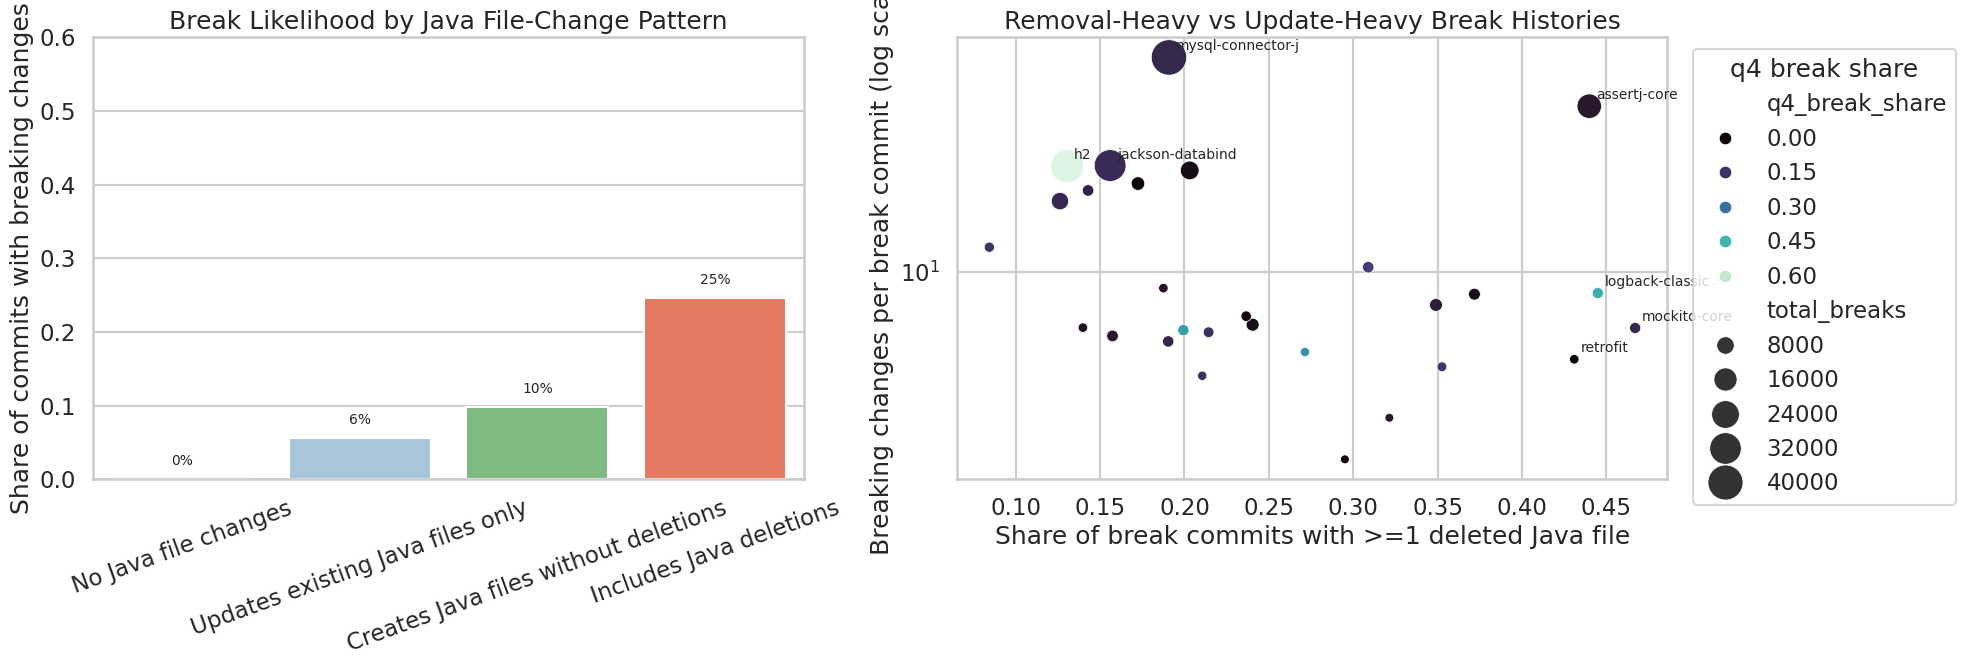

In [4]:
bucket_display = bucket_summary[[
    "commits",
    "share_of_commits",
    "share_of_break_commits",
    "break_rate",
    "mean_breaks",
]].round(3)
display(bucket_display)

file_signal_df = profile_df.reset_index().query("break_commits >= 20").copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

bucket_plot = bucket_summary.reset_index()
sns.barplot(
    data=bucket_plot,
    x="change_bucket",
    y="break_rate",
    palette=["#d9d9d9", "#9ecae1", "#74c476", "#fb6a4a"],
    ax=axes[0],
)
axes[0].set_title("Break Likelihood by Java File-Change Pattern")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of commits with breaking changes")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylim(0, max(0.6, float(bucket_plot["break_rate"].max()) + 0.05))
for patch, (_, row) in zip(axes[0].patches, bucket_plot.iterrows()):
    axes[0].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.015,
        f"{row['break_rate']:.0%}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

sns.scatterplot(
    data=file_signal_df,
    x="deleted_break_commit_share",
    y="breaks_per_break_commit",
    size="total_breaks",
    hue="q4_break_share",
    palette="mako",
    sizes=(40, 650),
    ax=axes[1],
)
axes[1].set_yscale("log")
axes[1].set_title("Removal-Heavy vs Update-Heavy Break Histories")
axes[1].set_xlabel("Share of break commits with >=1 deleted Java file")
axes[1].set_ylabel("Breaking changes per break commit (log scale)")
annotated_file_signal_libraries = pd.Index(
    file_signal_df.nlargest(4, "total_breaks")["library"].tolist()
    + file_signal_df.nlargest(4, "deleted_break_commit_share")["library"].tolist()
).unique()
for lib in annotated_file_signal_libraries:
    row = file_signal_df[file_signal_df["library"] == lib]
    if row.empty:
        continue
    row = row.iloc[0]
    axes[1].annotate(
        lib,
        (row["deleted_break_commit_share"], row["breaks_per_break_commit"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )
axes[1].legend(title="q4 break share", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

## Cross-Library Shapes of API Evolution and Break Introduction

The next figure compares the histories after normalizing them by relative progress through the history. This makes it possible to compare libraries of very different sizes and ages on the same scale.

- The left heatmap shows the exported API size as a fraction of the library's own peak API size.
- The right heatmap shows where the public-API breaking-change volume is located in the history.

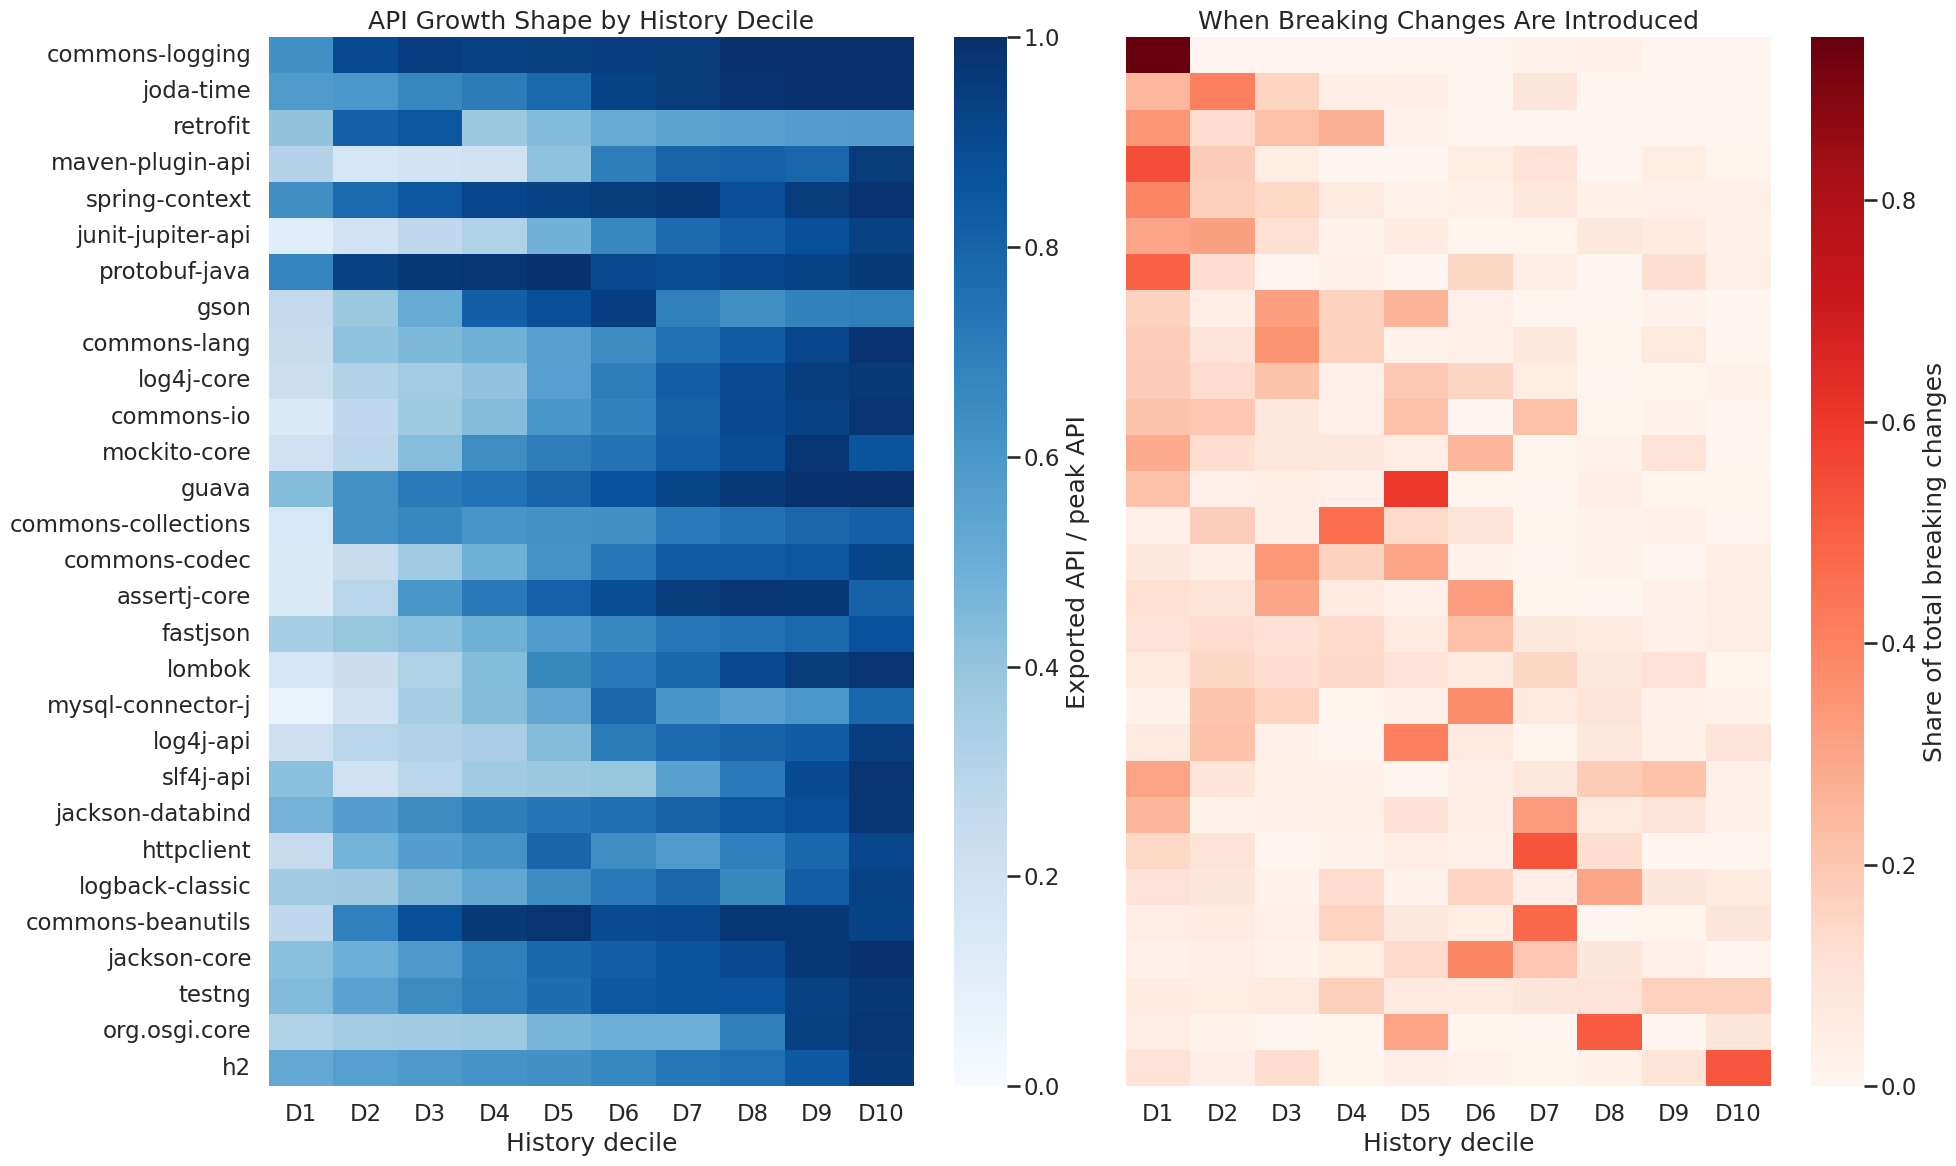

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, max(12, 0.4 * len(heatmap_order))), sharey=True)

sns.heatmap(
    api_shape.loc[heatmap_order],
    cmap="Blues",
    vmin=0,
    vmax=1,
    yticklabels=heatmap_labels,
    xticklabels=[f"D{i}" for i in range(1, 11)],
    ax=axes[0],
    cbar_kws={"label": "Exported API / peak API"},
)
axes[0].set_title("API Growth Shape by History Decile")
axes[0].set_xlabel("History decile")
axes[0].set_ylabel("")

sns.heatmap(
    break_shape.loc[heatmap_order],
    cmap="Reds",
    vmin=0,
    vmax=max(0.35, float(break_shape.max().max())),
    yticklabels=heatmap_labels,
    xticklabels=[f"D{i}" for i in range(1, 11)],
    ax=axes[1],
    cbar_kws={"label": "Share of total breaking changes"},
)
axes[1].set_title("When Breaking Changes Are Introduced")
axes[1].set_xlabel("History decile")
axes[1].set_ylabel("")

plt.tight_layout()

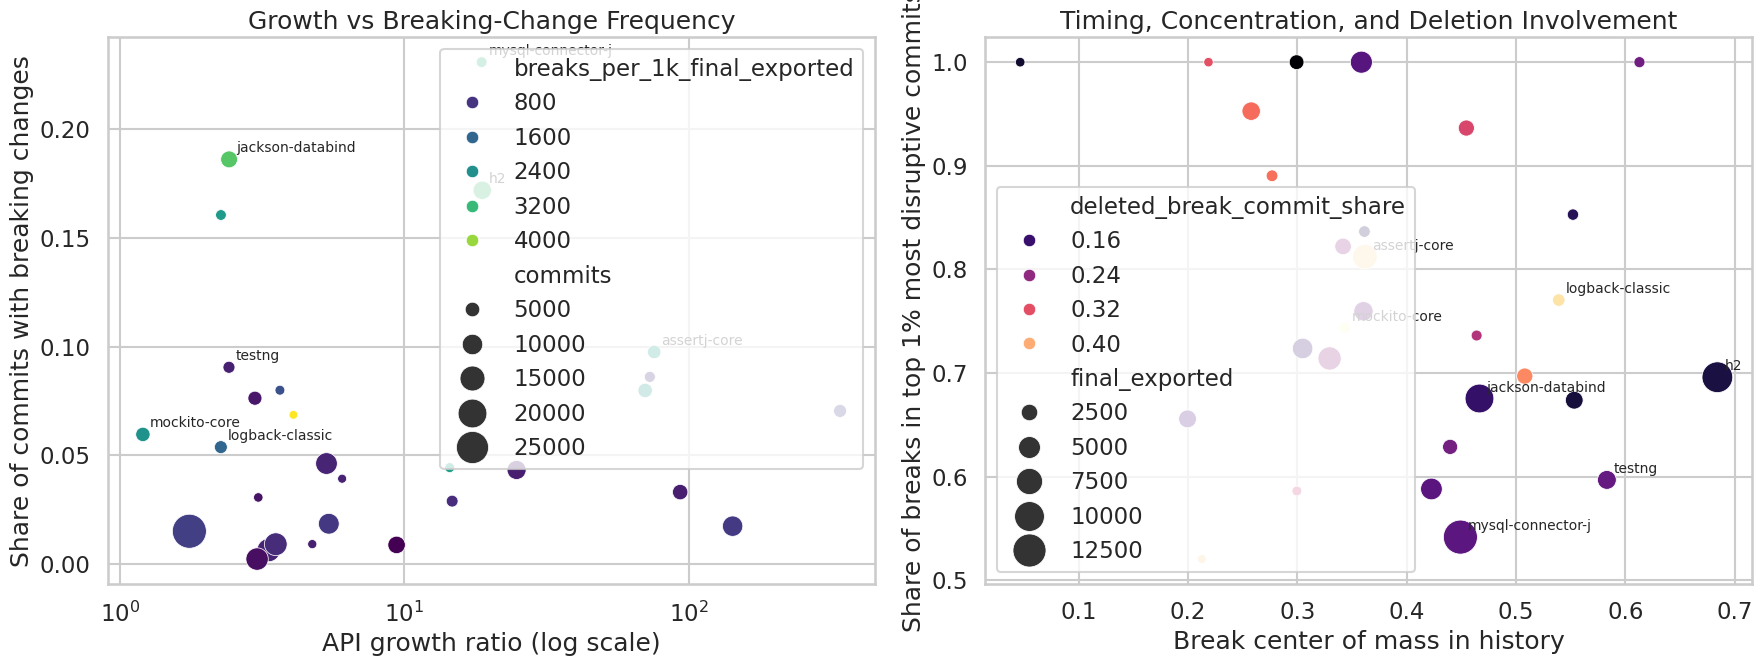

In [6]:
scatter_df = profile_df.reset_index().copy()
scatter_df["growth_ratio_clipped"] = scatter_df["growth_ratio"].clip(lower=0.5)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=scatter_df,
    x="growth_ratio_clipped",
    y="break_commit_share",
    size="commits",
    hue="breaks_per_1k_final_exported",
    palette="viridis",
    sizes=(40, 600),
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_xlabel("API growth ratio (log scale)")
axes[0].set_ylabel("Share of commits with breaking changes")
axes[0].set_title("Growth vs Breaking-Change Frequency")

sns.scatterplot(
    data=scatter_df,
    x="break_center",
    y="top1pct_break_share",
    size="final_exported",
    hue="deleted_break_commit_share",
    palette="magma",
    sizes=(40, 600),
    ax=axes[1],
)
axes[1].set_xlabel("Break center of mass in history")
axes[1].set_ylabel("Share of breaks in top 1% most disruptive commits")
axes[1].set_title("Timing, Concentration, and Deletion Involvement")

annotated_libraries = pd.Index(
    scatter_df.nlargest(3, "total_breaks")["library"].tolist()
    + scatter_df.nlargest(3, "q4_break_share")["library"].tolist()
    + scatter_df.nlargest(3, "deleted_break_commit_share")["library"].tolist()
).unique()
for lib in annotated_libraries:
    row = scatter_df[scatter_df["library"] == lib].iloc[0]
    axes[0].annotate(lib, (row["growth_ratio_clipped"], row["break_commit_share"]), xytext=(5, 5), textcoords="offset points", fontsize=10)
    axes[1].annotate(lib, (row["break_center"], row["top1pct_break_share"]), xytext=(5, 5), textcoords="offset points", fontsize=10)

plt.tight_layout()

## Public vs Excluded/Internal Breaking Changes

The main longitudinal analysis above intentionally focuses on **public-API breaking changes** (`api_breaking_changes_count`).

The table and figures below keep that as the primary signal and then document, separately, how much additional breakage falls on excluded or internal symbols.

In [7]:
display(scope_summary)

top_public_breaks = profile_df["total_breaks"].sort_values(ascending=False).head(5)
top_excluded_share = profile_df["excluded_break_share"].dropna().sort_values(ascending=False).head(5)
scope_lines = [
    f"- Across the full corpus, the main public-API analysis covers **{int(profile_df['total_breaks'].sum()):,}** breaking changes, while excluded/internal symbols account for an additional **{int(profile_df['total_excluded_breaks'].sum()):,}** detected breaks.",
    f"- The median library routes **{profile_df['excluded_break_share'].dropna().median():.1%}** of its detected break rows to excluded/internal symbols rather than the public API.",
    f"- Libraries with the largest public-API break volume are **{', '.join(f'{lib} ({int(val):,})' for lib, val in top_public_breaks.items())}**.",
    f"- Libraries with the largest excluded/internal share are **{', '.join(f'{lib} ({val:.0%})' for lib, val in top_excluded_share.items())}**.",
]

display(Markdown("\n".join(scope_lines)))

,commits,years_span,final_exported,growth_ratio,break_commit_share,api_change_share,total_breaks,total_excluded_breaks,excluded_break_share,deleted_break_commit_share,q1_break_share,q4_break_share
library,,,,,,,,,,,,
mysql-connector-j,2633,23.765,13280.0,18.678,0.231,0.430,40918.0,2202.0,0.051,0.191,0.377,0.118
h2,8024,19.129,10683.0,18.775,0.172,0.298,35406.0,0.0,0.000,0.130,0.157,0.635
jackson-databind,6751,14.248,9264.0,2.419,0.186,0.359,32414.0,3070.0,0.087,0.156,0.280,0.130
assertj-core,4263,15.546,6493.0,75.500,0.098,0.269,18165.0,1002.0,0.052,0.440,0.454,0.068
commons-collections,4869,24.939,3719.0,70.170,0.080,0.184,9606.0,0.0,0.000,0.203,0.235,0.031
jackson-core,2615,14.245,3016.0,2.264,0.161,0.330,7897.0,0.0,0.000,0.126,0.080,0.122
joda-time,2175,22.220,3040.0,3.649,0.080,0.185,3823.0,0.0,0.000,0.172,0.809,0.002
log4j-core,11238,14.105,5757.0,5.321,0.046,0.114,3267.0,207.0,0.060,0.240,0.503,0.033
spring-context,28055,17.418,3319.0,1.753,0.015,0.035,3174.0,0.0,0.000,0.349,0.687,0.085


- Across the full corpus, the main public-API analysis covers **177,563** breaking changes, while excluded/internal symbols account for an additional **17,037** detected breaks.
- The median library routes **1.2%** of its detected break rows to excluded/internal symbols rather than the public API.
- Libraries with the largest public-API break volume are **mysql-connector-j (40,918), h2 (35,406), jackson-databind (32,414), assertj-core (18,165), commons-collections (9,606)**.
- Libraries with the largest excluded/internal share are **gson (79%), guava (75%), mockito-core (67%), testng (50%), httpclient (50%)**.

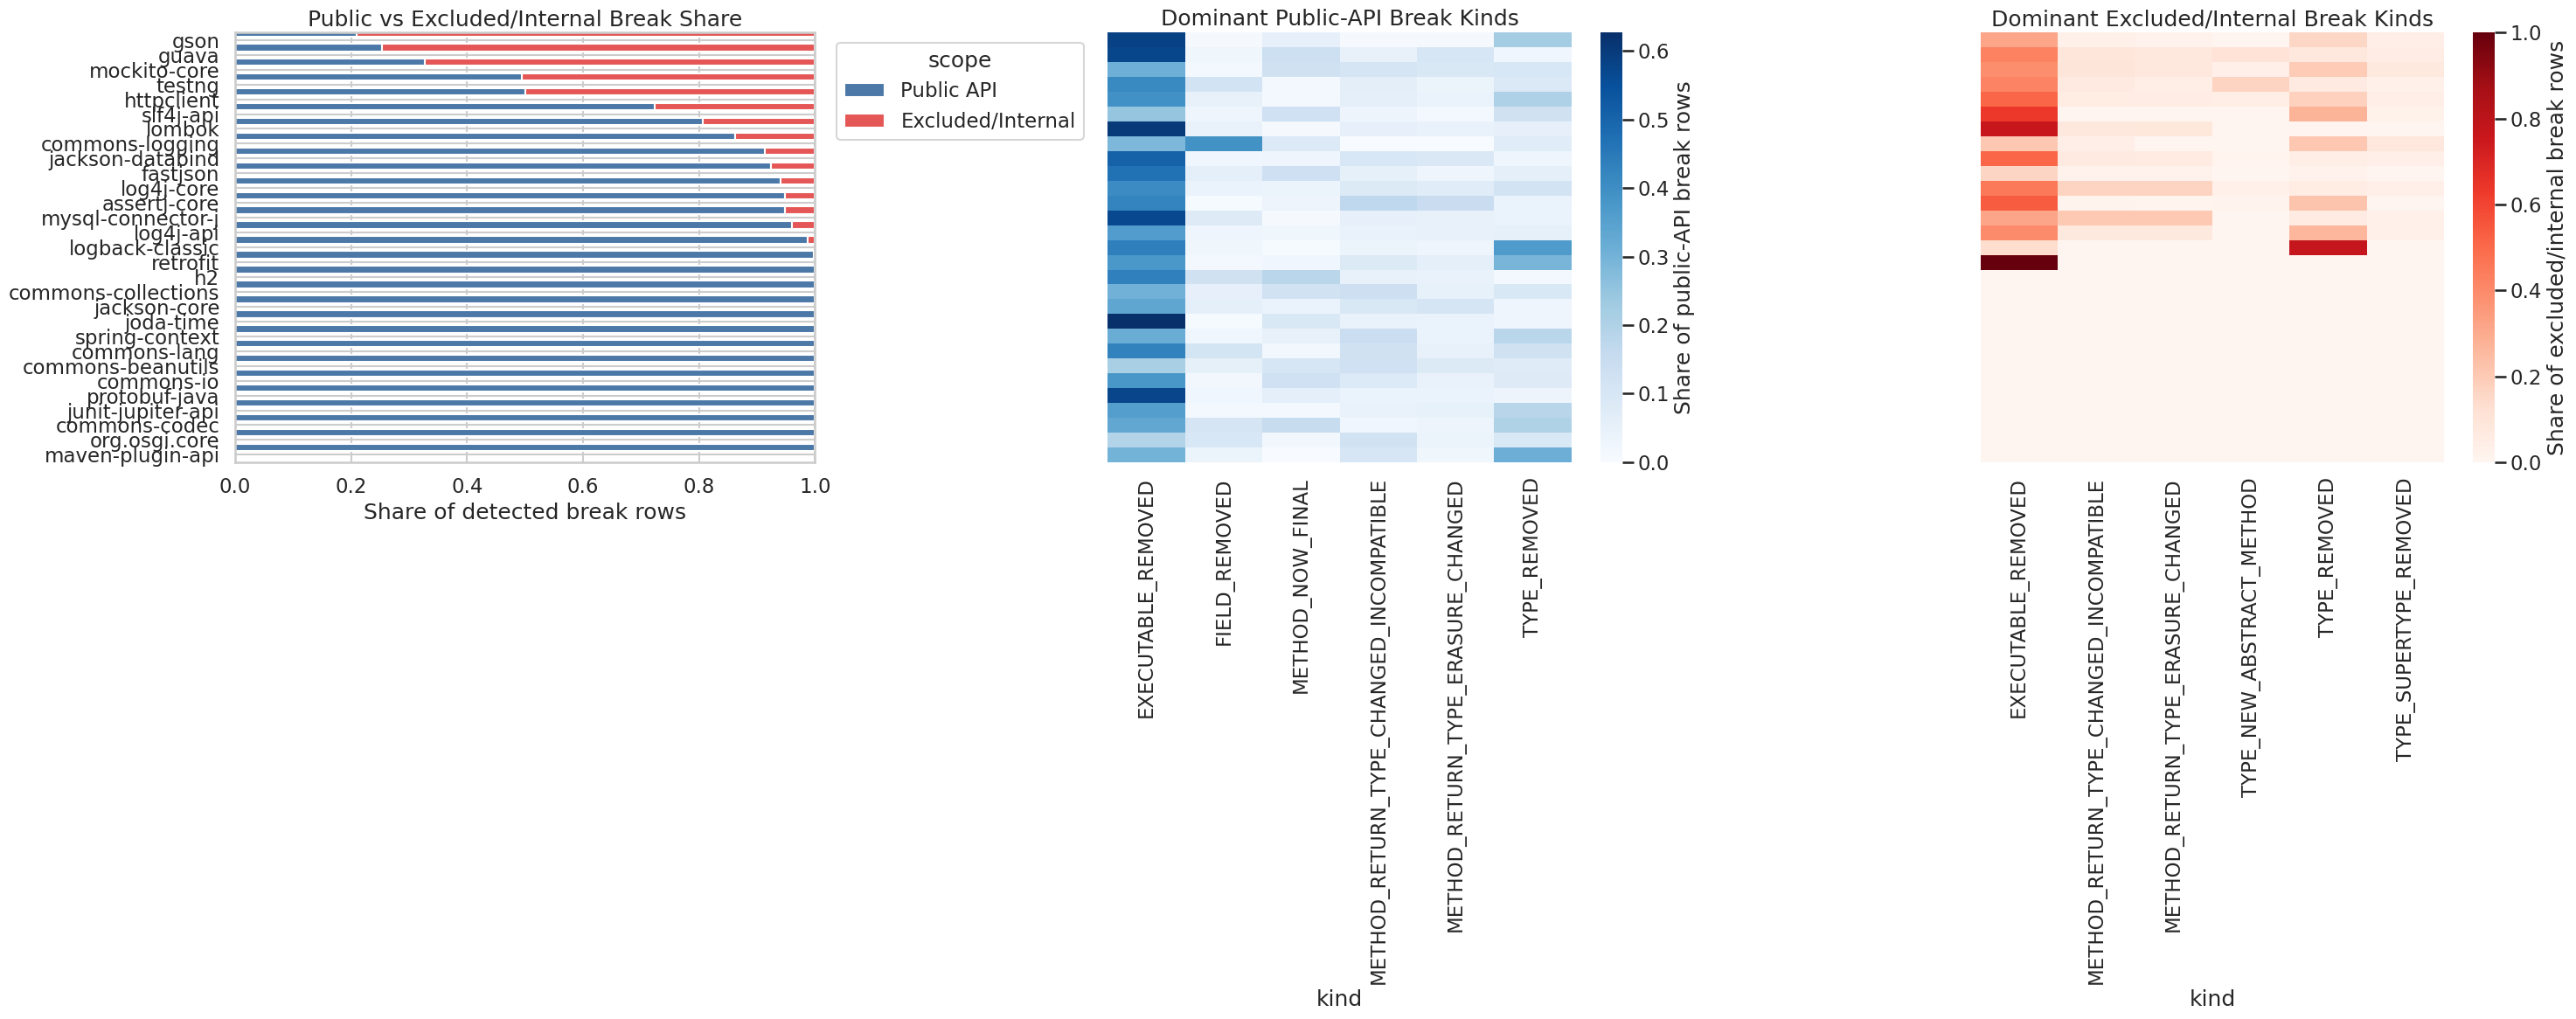

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(30, max(12, 0.35 * len(scope_order))), sharey=True)

break_scope_share.plot(
    kind="barh",
    stacked=True,
    ax=axes[0],
    color=["#4c78a8", "#e45756"],
)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Share of detected break rows")
axes[0].set_ylabel("")
axes[0].set_title("Public vs Excluded/Internal Break Share")
axes[0].legend(title="scope", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.heatmap(
    public_kind_matrix,
    cmap="Blues",
    vmin=0,
    vmax=max(0.35, float(public_kind_matrix.max().max())),
    yticklabels=scope_order,
    ax=axes[1],
    cbar_kws={"label": "Share of public-API break rows"},
)
axes[1].set_title("Dominant Public-API Break Kinds")
axes[1].set_xlabel("kind")
axes[1].set_ylabel("")

sns.heatmap(
    non_public_kind_matrix,
    cmap="Reds",
    vmin=0,
    vmax=max(0.35, float(non_public_kind_matrix.max().max())),
    yticklabels=scope_order,
    ax=axes[2],
    cbar_kws={"label": "Share of excluded/internal break rows"},
)
axes[2].set_title("Dominant Excluded/Internal Break Kinds")
axes[2].set_xlabel("kind")
axes[2].set_ylabel("")

plt.tight_layout()

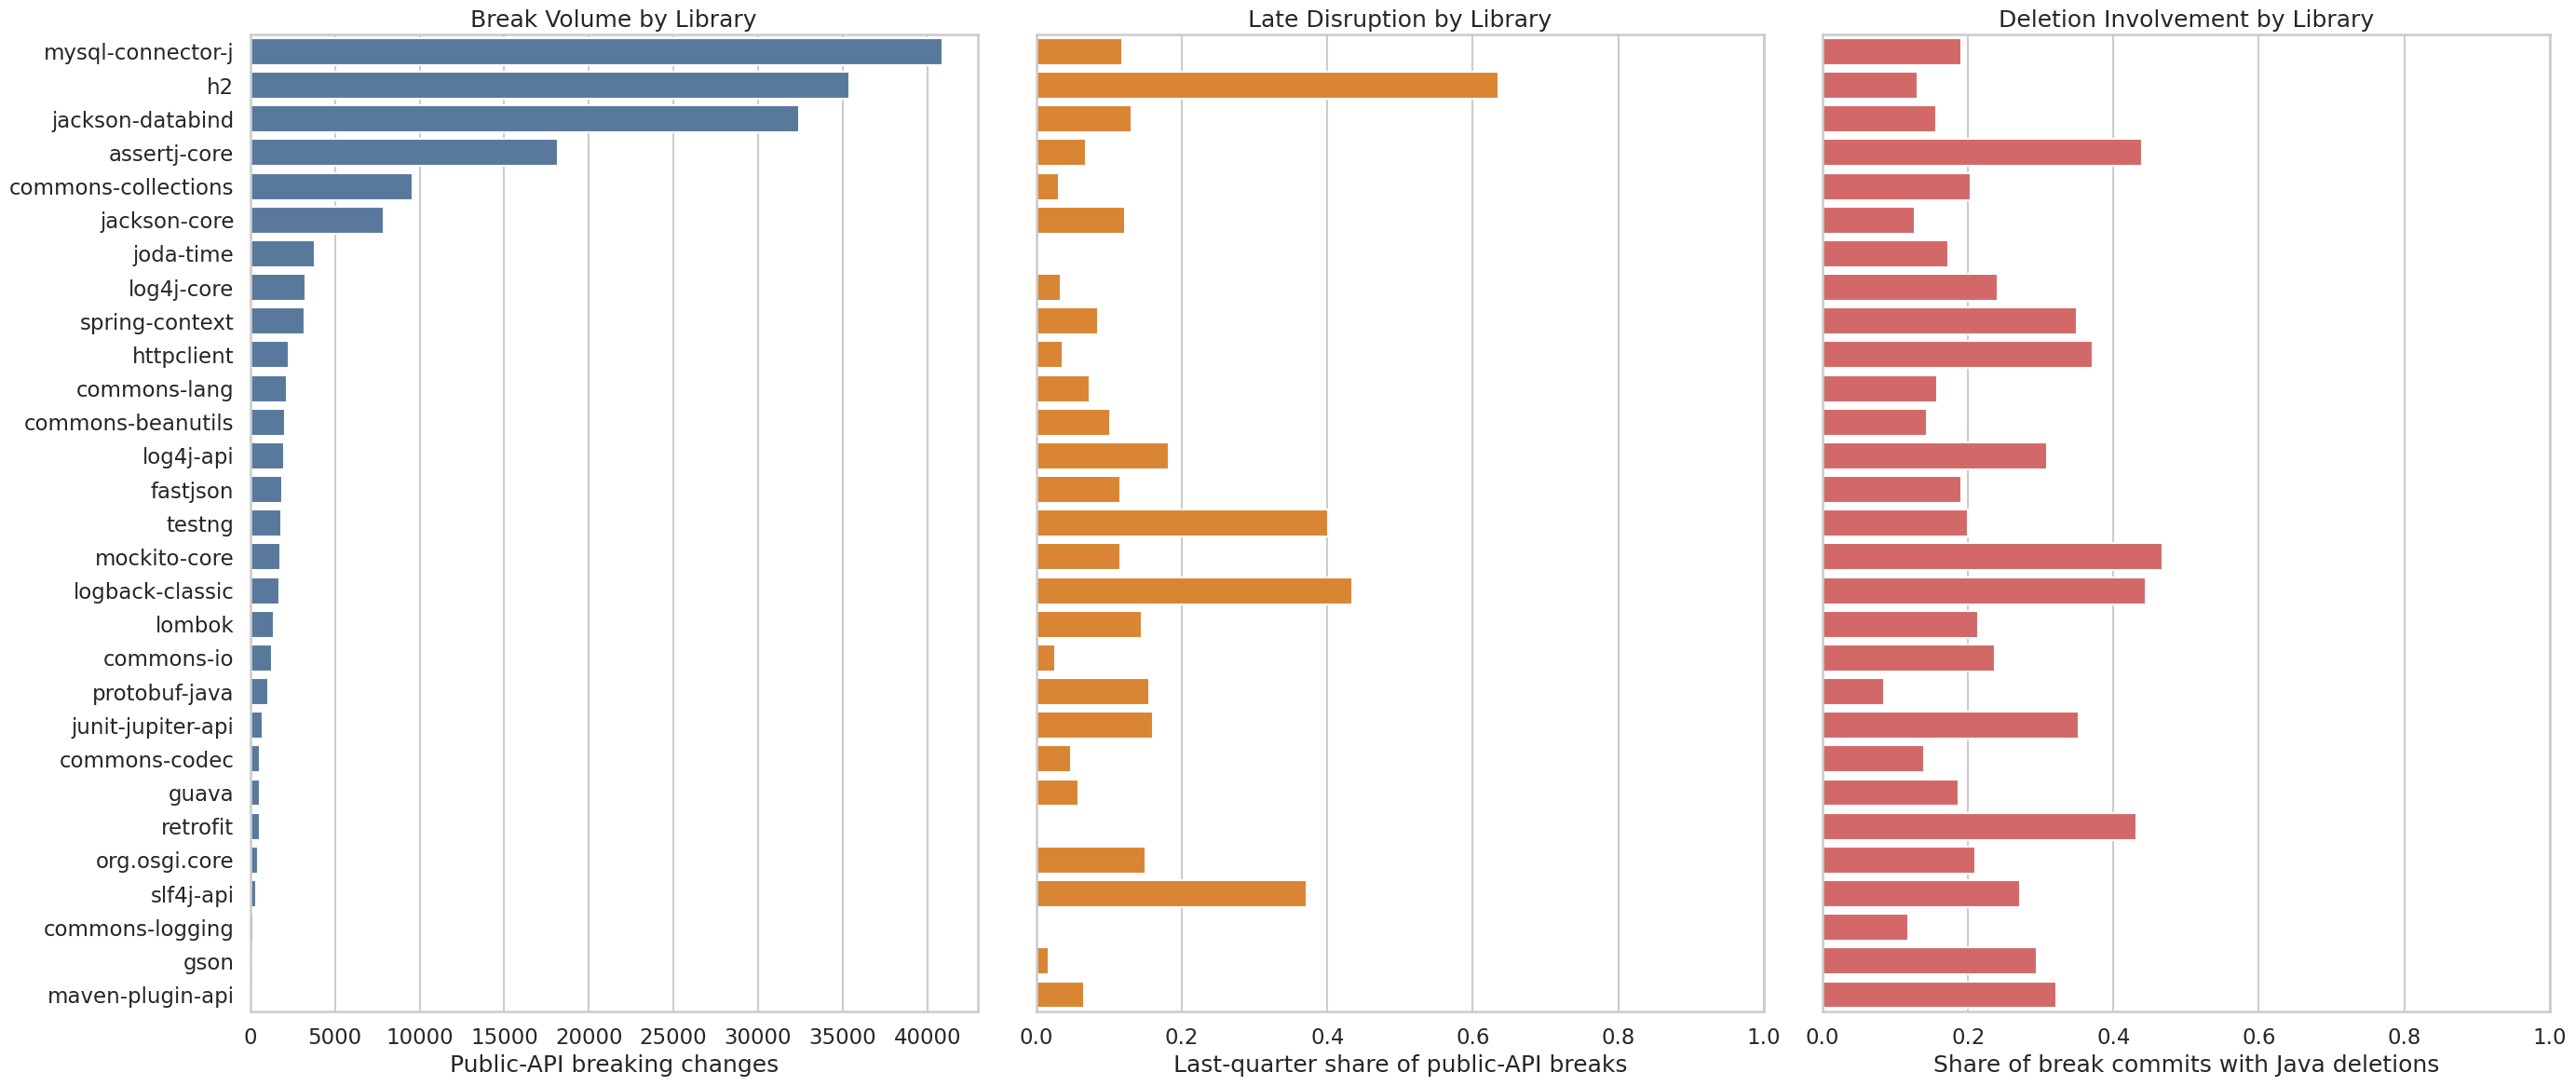

In [9]:
plot_df = selection_plot_df.copy()
plot_df = plot_df.sort_values("total_breaks", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(28, max(12, 0.35 * len(plot_df))), sharey=True)

sns.barplot(data=plot_df, y="library", x="total_breaks", ax=axes[0], color="#4c78a8")
axes[0].set_xlabel("Public-API breaking changes")
axes[0].set_ylabel("")
axes[0].set_title("Break Volume by Library")

sns.barplot(data=plot_df.sort_values("q4_break_share", ascending=False), y="library", x="q4_break_share", ax=axes[1], color="#f58518")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Last-quarter share of public-API breaks")
axes[1].set_ylabel("")
axes[1].set_title("Late Disruption by Library")

sns.barplot(data=plot_df.sort_values("deleted_break_commit_share", ascending=False), y="library", x="deleted_break_commit_share", ax=axes[2], color="#e45756")
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("Share of break commits with Java deletions")
axes[2].set_ylabel("")
axes[2].set_title("Deletion Involvement by Library")

plt.tight_layout()

## All-library Evolution

In [10]:
compact_bin_count = 30
compact_x = np.linspace(0, 1, compact_bin_count)
compact_bar_x = np.arange(compact_bin_count) / compact_bin_count
compact_order = profile_df.sort_values(["break_center", "total_breaks"], ascending=[True, False]).index.tolist()
compact_y = np.arange(len(compact_order))[::-1]

compact_timelines = timelines_df.copy()
compact_timelines["history_bin"] = np.clip(
    np.floor(compact_timelines["history_pct"] * compact_bin_count).astype(int),
    0,
    compact_bin_count - 1,
)

compact_api_shape = (
    compact_timelines.groupby(["library", "history_bin"])["api_relative_to_peak"]
    .mean()
    .unstack(fill_value=0)
    .reindex(index=compact_order, columns=range(compact_bin_count), fill_value=0)
)

compact_break_share = (
    compact_timelines.groupby(["library", "history_bin"])["breaking_changes_count"]
    .sum()
    .unstack(fill_value=0)
    .reindex(index=compact_order, columns=range(compact_bin_count), fill_value=0)
)
compact_break_share = compact_break_share.div(
    compact_break_share.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0)

compact_break_intensity = (
    compact_timelines.groupby(["library", "history_bin"])["breaking_changes_count"]
    .sum()
    .unstack(fill_value=0)
    .reindex(index=compact_order, columns=range(compact_bin_count), fill_value=0)
)
compact_break_intensity = compact_break_intensity.div(
    compact_break_intensity.max(axis=1).replace(0, np.nan), axis=0
).fillna(0)

break_events_df = compact_timelines[compact_timelines["breaking_changes_count"] > 0][[
    "library",
    "history_pct",
    "breaking_changes_count",
]].copy()
break_events_df["linewidth"] = break_events_df["breaking_changes_count"].clip(
    upper=break_events_df["breaking_changes_count"].quantile(0.95)
)
break_events_df["linewidth"] = 0.4 + 2.6 * (
    break_events_df["linewidth"] / break_events_df["linewidth"].max()
)

glyph_df = profile_df.loc[compact_order, [
    "growth_ratio",
    "break_commit_share",
    "q4_break_share",
    "deleted_break_commit_share",
    "excluded_break_share",
    "total_breaks",
    "break_center",
]].copy()
glyph_df["growth_ratio_clipped"] = glyph_df["growth_ratio"].clip(
    upper=glyph_df["growth_ratio"].quantile(0.95)
)
glyph_df["growth_ratio_scaled"] = glyph_df["growth_ratio_clipped"] / glyph_df["growth_ratio_clipped"].max()
glyph_df["total_breaks_scaled"] = glyph_df["total_breaks"] / glyph_df["total_breaks"].max()


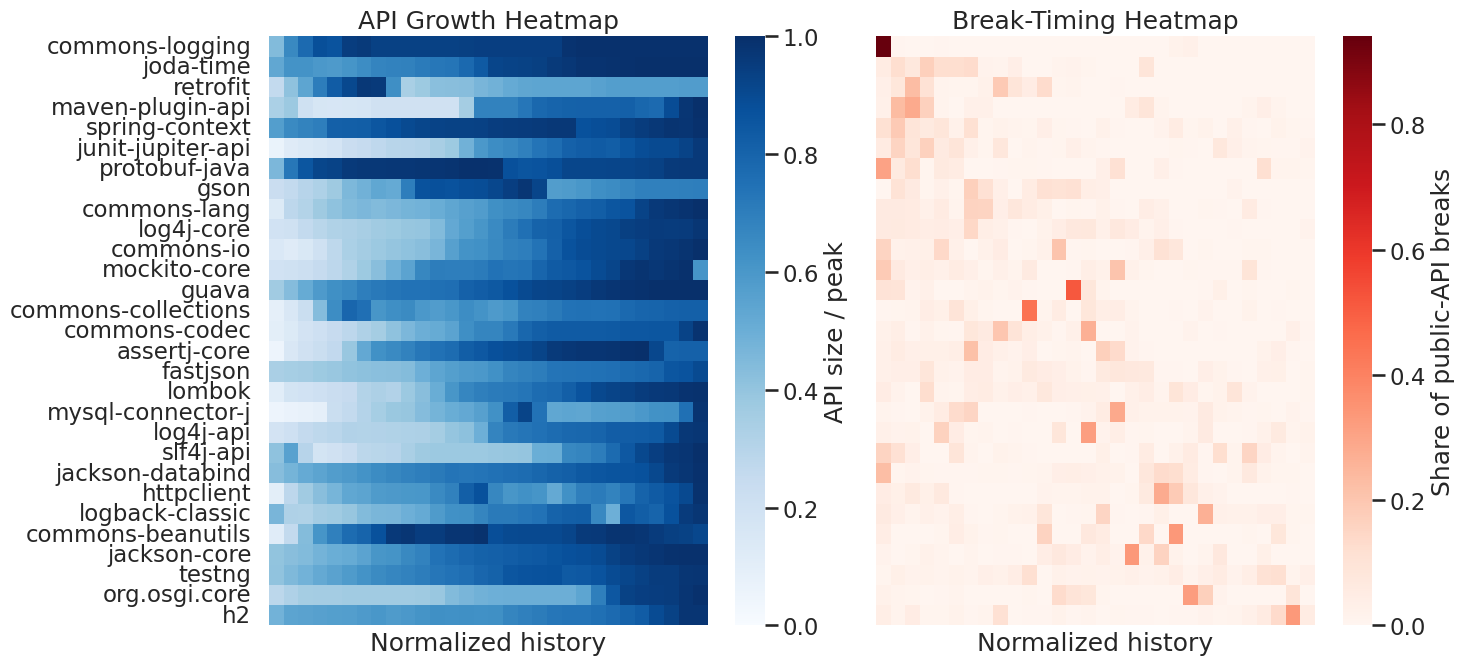

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(7, 0.22 * len(compact_order))), sharey=True)

sns.heatmap(
    compact_api_shape,
    cmap="Blues",
    vmin=0,
    vmax=1,
    yticklabels=compact_order,
    xticklabels=False,
    ax=axes[0],
    cbar_kws={"label": "API size / peak"},
)
axes[0].set_title("API Growth Heatmap")
axes[0].set_xlabel("Normalized history")
axes[0].set_ylabel("")

sns.heatmap(
    compact_break_share,
    cmap="Reds",
    vmin=0,
    vmax=max(0.2, float(compact_break_share.max().max())),
    yticklabels=compact_order,
    xticklabels=False,
    ax=axes[1],
    cbar_kws={"label": "Share of public-API breaks"},
)
axes[1].set_title("Break-Timing Heatmap")
axes[1].set_xlabel("Normalized history")
axes[1].set_ylabel("")

plt.tight_layout()


## Ridgelines

These variants keep the same library ordering and normalized-history x-axis while exploring different ways to combine API evolution and public-API breaking changes in a compact ridge-based figure.


In [12]:
ridge_kernel = np.array([1, 2, 3, 2, 1], dtype=float)
ridge_kernel /= ridge_kernel.sum()
ridge_edges = np.linspace(0, 1, compact_bin_count + 1)

def smooth_ridge(values):
    return np.convolve(np.asarray(values, dtype=float), ridge_kernel, mode="same")

ridge_api_profile = pd.DataFrame(
    np.vstack([smooth_ridge(compact_api_shape.loc[lib].to_numpy()) for lib in compact_order]),
    index=compact_order,
    columns=compact_api_shape.columns,
)
ridge_break_profile = pd.DataFrame(
    np.vstack([smooth_ridge(compact_break_intensity.loc[lib].to_numpy()) for lib in compact_order]),
    index=compact_order,
    columns=compact_break_intensity.columns,
)
ridge_break_share_profile = pd.DataFrame(
    np.vstack([smooth_ridge(compact_break_share.loc[lib].to_numpy()) for lib in compact_order]),
    index=compact_order,
    columns=compact_break_share.columns,
)

ridge_spacing = 1.15
ridge_y = (np.arange(len(compact_order))[::-1] * ridge_spacing).astype(float)
ridge_break_ticks = break_events_df.copy()
ridge_break_ticks["tick_height"] = 0.12 + 0.48 * (
    ridge_break_ticks["breaking_changes_count"] / ridge_break_ticks["breaking_changes_count"].max()
)


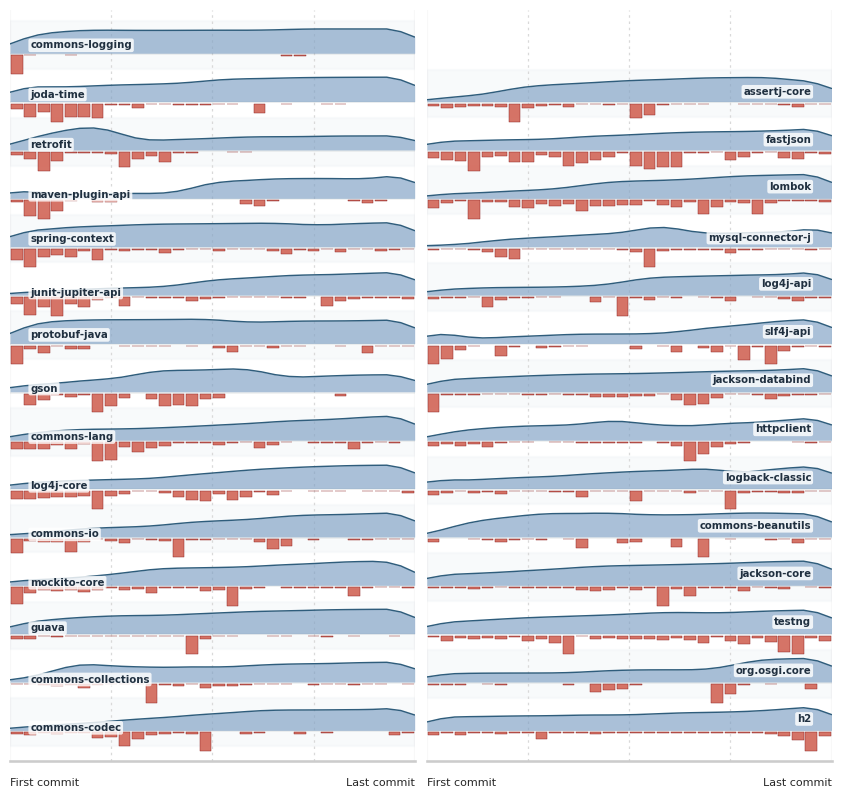

In [13]:
split_mid = int(np.ceil(len(compact_order) / 2))
split_groups = [compact_order[:split_mid], compact_order[split_mid:]]

api_scale = 0.58
break_scale = 0.44
bar_width = 0.86 / compact_bin_count
bar_centers = (ridge_edges[:-1] + ridge_edges[1:]) / 2

api_fill = "#7ea0c4"
api_line = "#2f5d7c"
break_fill = "#d36b5d"
break_line = "#8b1e1e"
baseline_color = "#7f8c8d"

split_max_rows = max(len(libs) for libs in split_groups)
split_y_max = (split_max_rows - 1) * ridge_spacing if split_max_rows else 0
split_fig_height = max(7.5, 0.65 * split_max_rows)
label_x_positions = [0.05, 0.95]
label_alignments = ["left", "right"]
label_box = {
    "boxstyle": "round,pad=0.18,rounding_size=0.2",
    "facecolor": "white",
    "edgecolor": "none",
    "alpha": 0.82,
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.6, split_fig_height),
    sharex=True,
    gridspec_kw={"wspace": 0.03},
)

for panel_idx, (ax, libs) in enumerate(zip(axes, split_groups)):
    local_y = (np.arange(len(libs))[::-1] * ridge_spacing).astype(float)
    label_x = label_x_positions[panel_idx]
    label_idx = np.abs(compact_x - label_x).argmin()

    for band_idx, baseline in enumerate(local_y):
        if band_idx % 2 == 0:
            ax.axhspan(baseline - 0.35, baseline + 0.78, color="#f4f6f8", alpha=0.55, zorder=0)

    for guide in [0.25, 0.5, 0.75]:
        ax.axvline(guide, color="#d9d9d9", linewidth=0.9, linestyle=(0, (2, 3)), zorder=1)

    for row, lib in enumerate(libs):
        baseline = local_y[row]
        api_series = ridge_api_profile.loc[lib].to_numpy()
        ridge_height = api_scale * api_series
        break_bins = compact_break_intensity.loc[lib].to_numpy()
        nonzero = break_bins > 0

        ax.hlines(baseline, 0, 1.0, color=baseline_color, linewidth=0.35, alpha=0.45, zorder=2)
        ax.fill_between(
            compact_x,
            baseline + 0.02,
            baseline + 0.02 + ridge_height,
            color=api_fill,
            alpha=0.66,
            linewidth=0,
            zorder=3,
        )
        ax.plot(
            compact_x,
            baseline + 0.02 + ridge_height,
            color=api_line,
            linewidth=1.05,
            zorder=4,
        )

        label_offset = min(max(0.06, 0.55 * ridge_height[label_idx]), max(ridge_height[label_idx] - 0.035, 0.06))
        ax.text(
            label_x,
            baseline + 0.02 + label_offset,
            lib,
            ha=label_alignments[panel_idx],
            va="center",
            fontsize=7.3,
            color="#203040",
            fontweight="semibold",
            bbox=label_box,
            zorder=6,
        )

        if nonzero.any():
            heights = break_scale * break_bins[nonzero]
            ax.bar(
                bar_centers[nonzero],
                heights,
                width=bar_width,
                bottom=baseline - heights - 0.03,
                color=break_fill,
                edgecolor=break_line,
                linewidth=0.35,
                alpha=0.94,
                align="center",
                zorder=5,
            )

    ax.set_yticks([])
    ax.set_xlim(0, 1.0)
    ax.set_ylim(-0.7, split_y_max + 1.05)
    ax.set_xticks([0, 1.0])
    ax.set_xticklabels(["First commit", "Last commit"], fontsize=8)
    labels = ax.get_xticklabels()
    labels[0].set_ha("left")
    labels[1].set_ha("right")
    ax.grid(axis="x", alpha=0.12)
    ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.savefig("figures/libs-ridge.pdf", bbox_inches="tight", pad_inches=0.02)


## Library Timelines

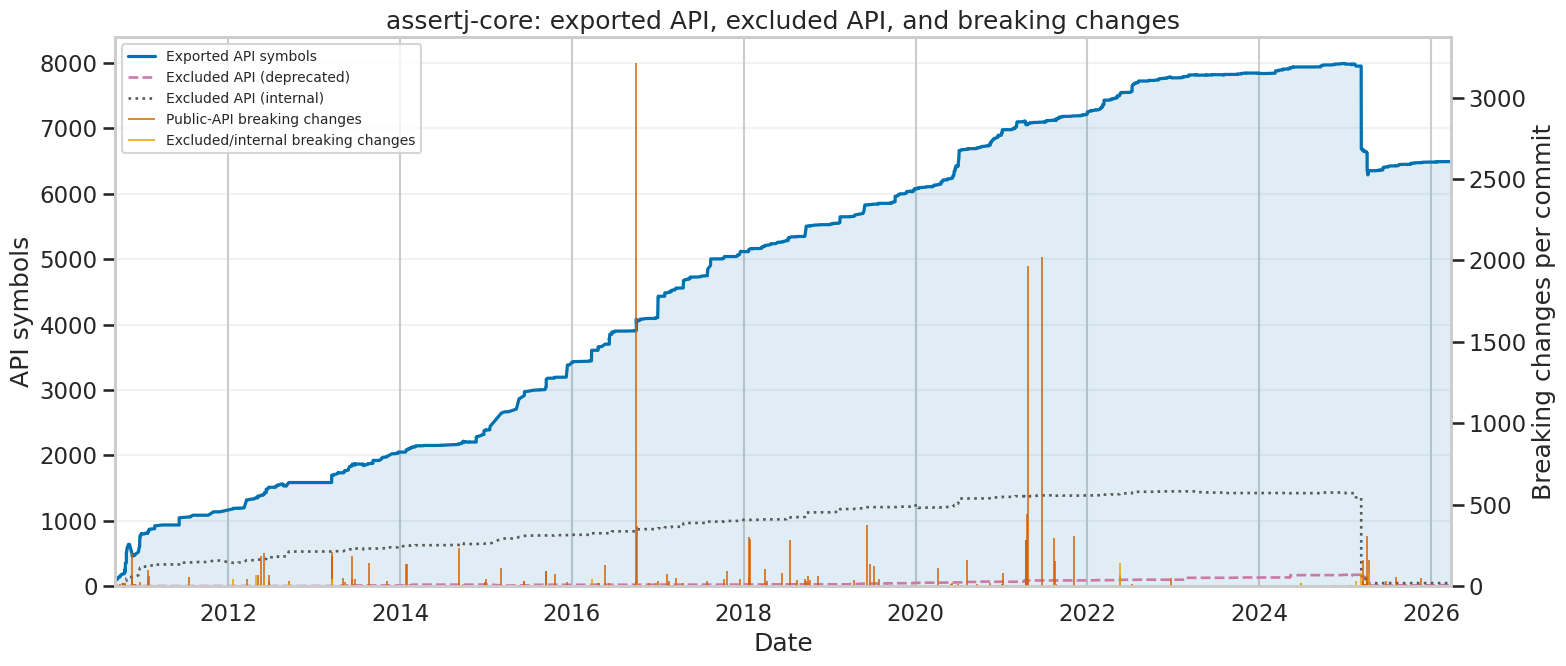

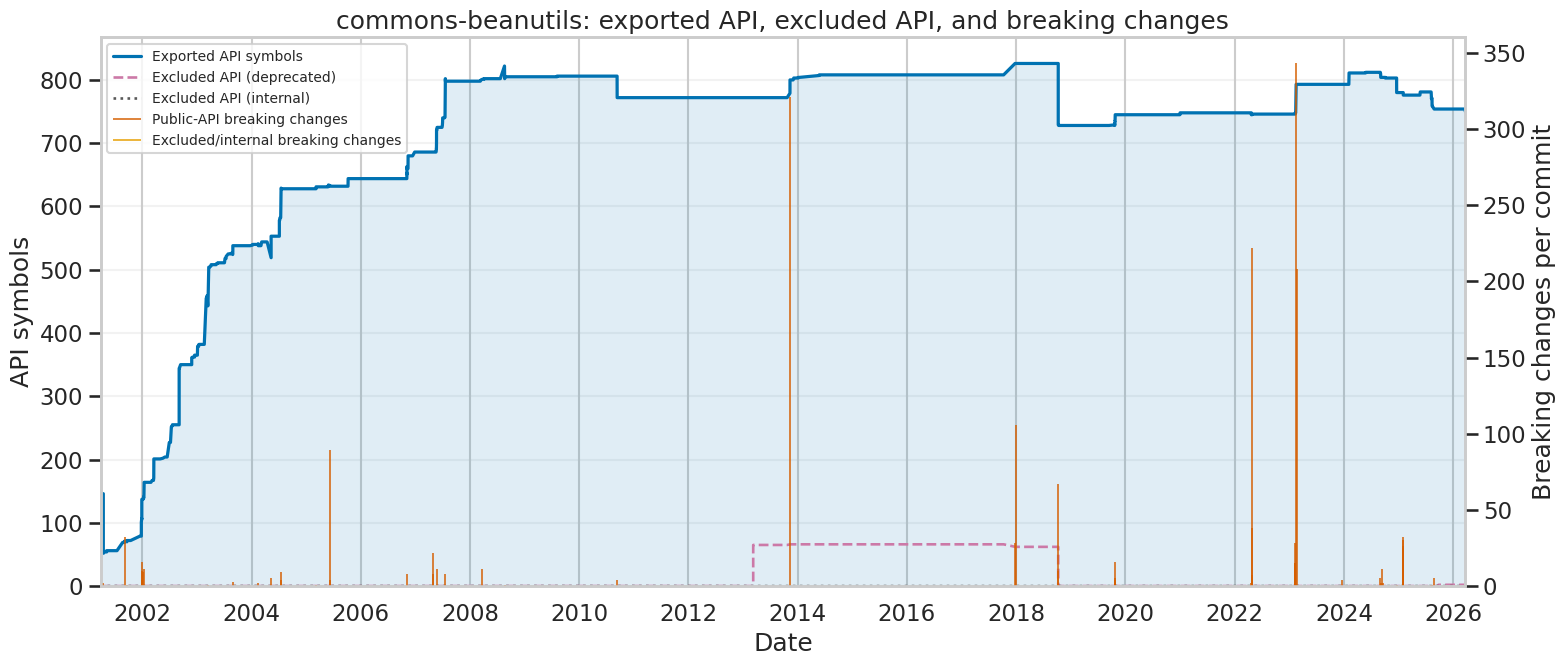

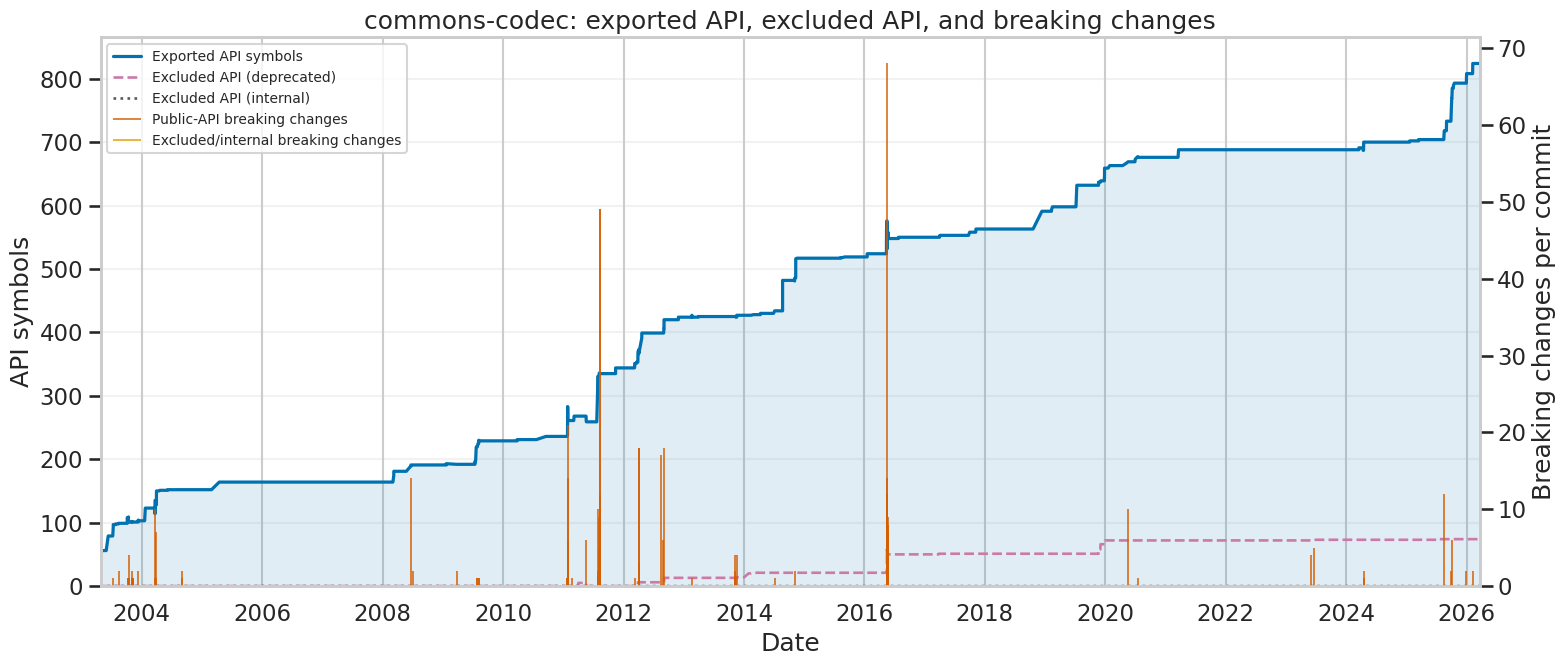

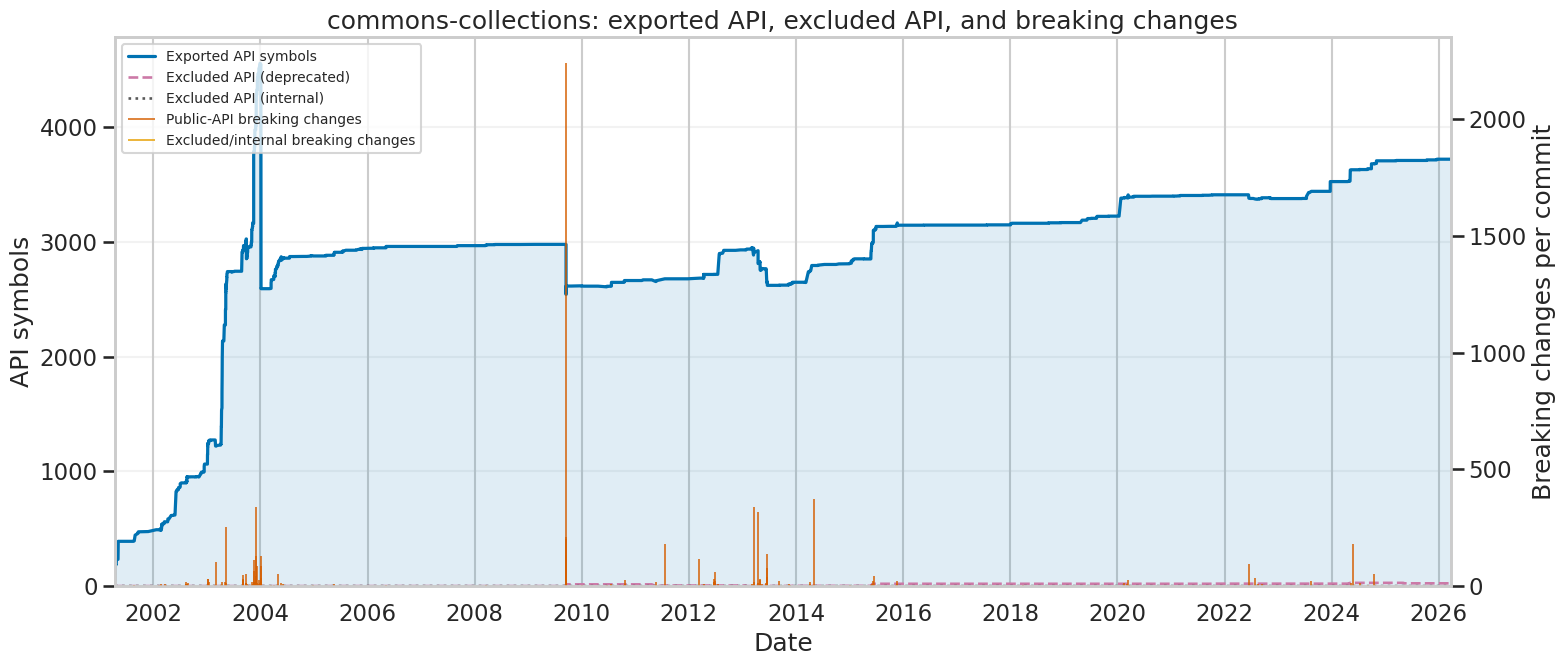

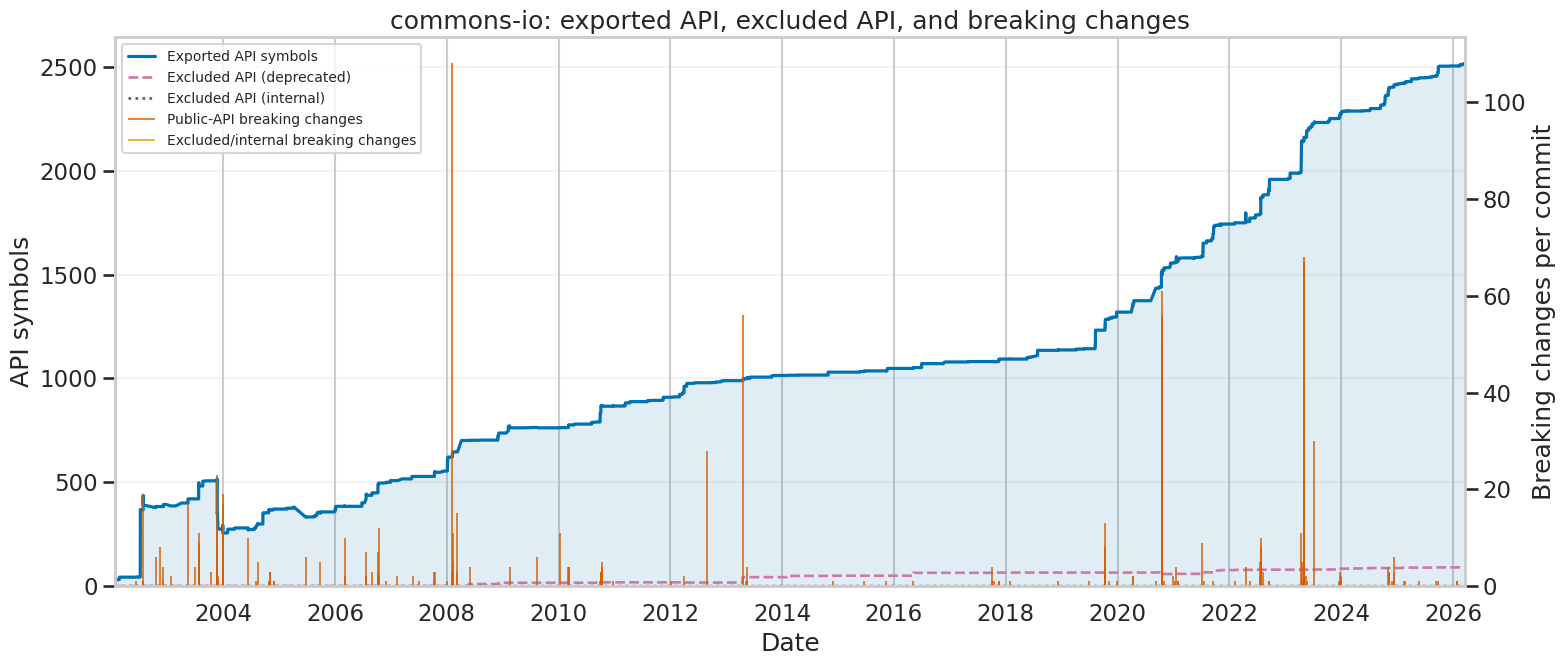

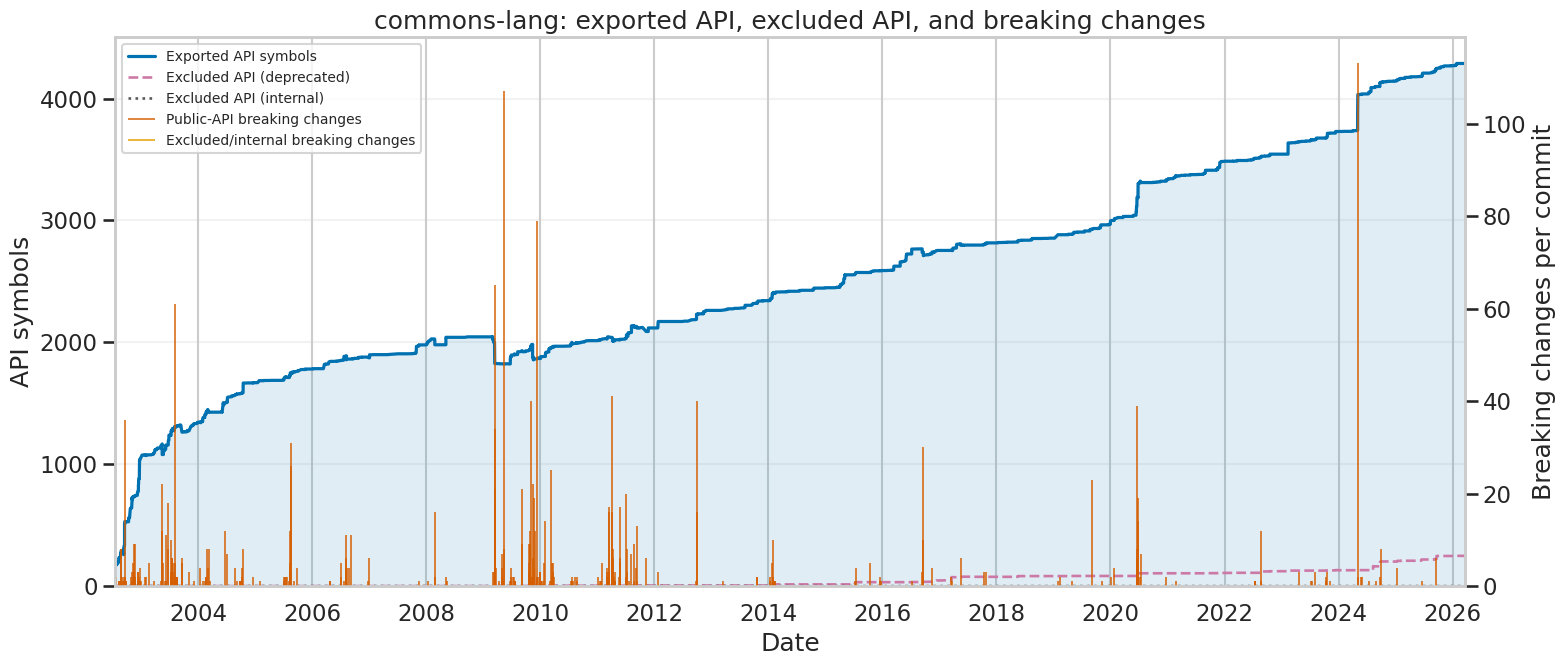

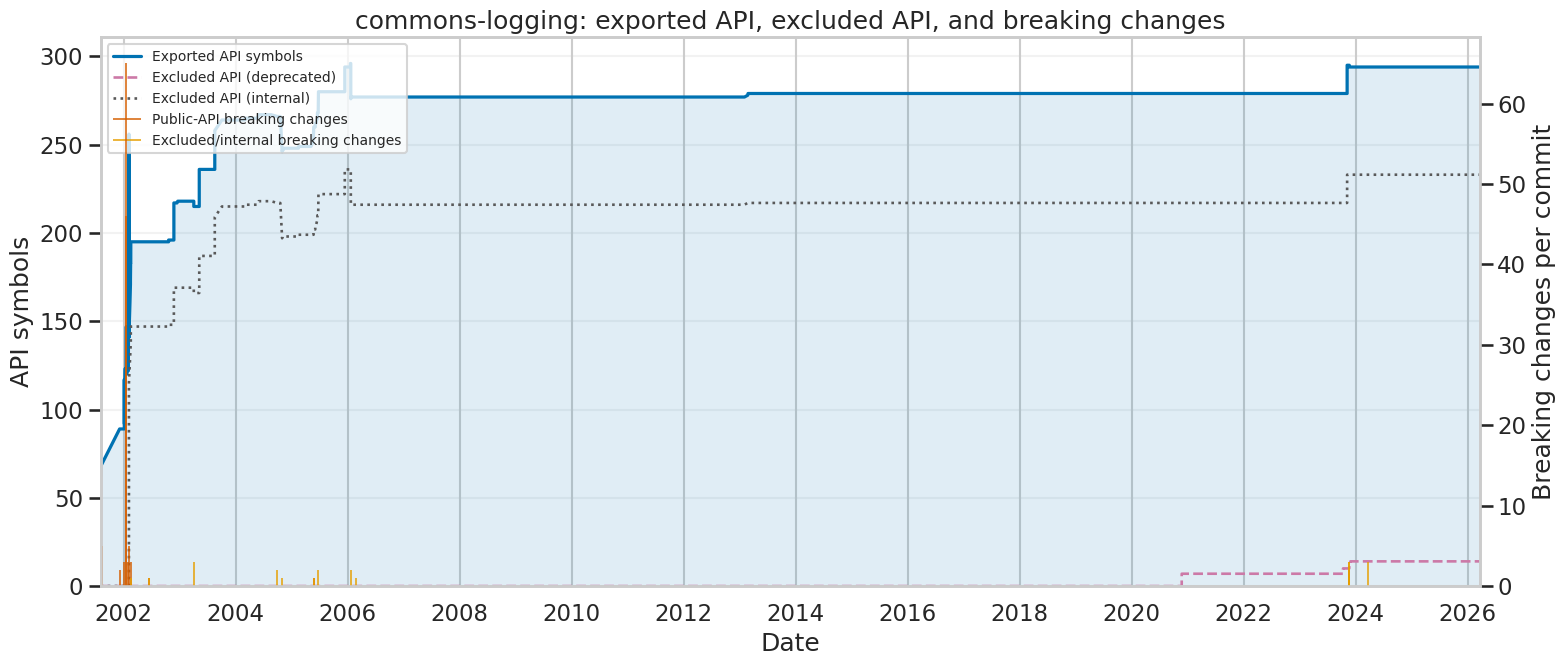

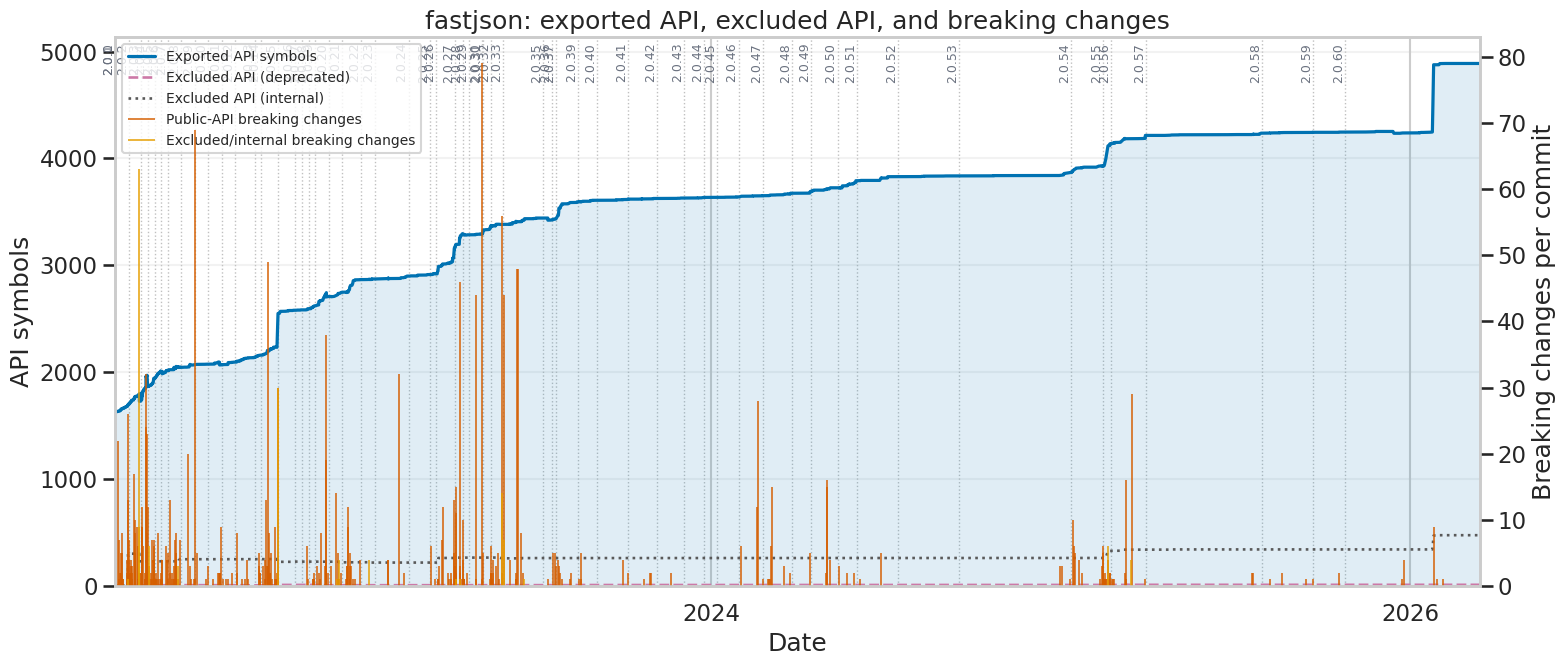

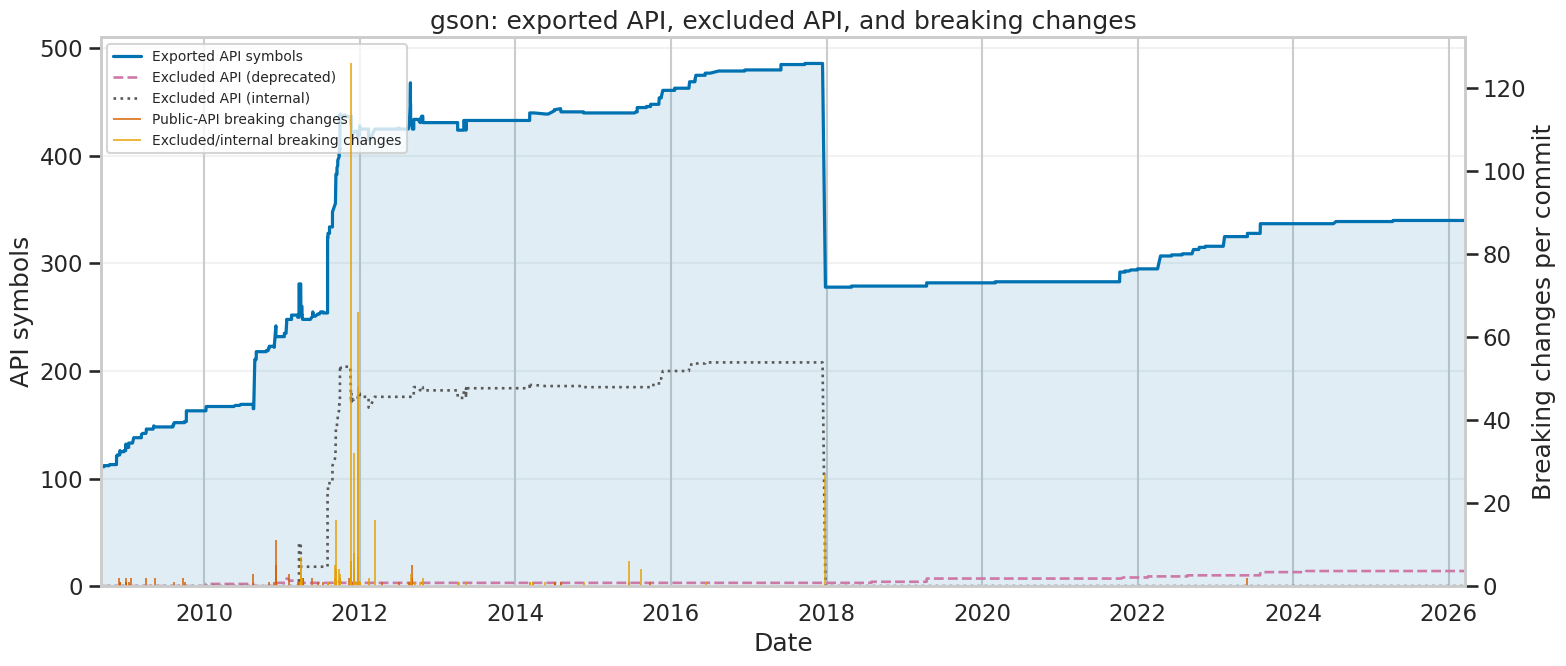

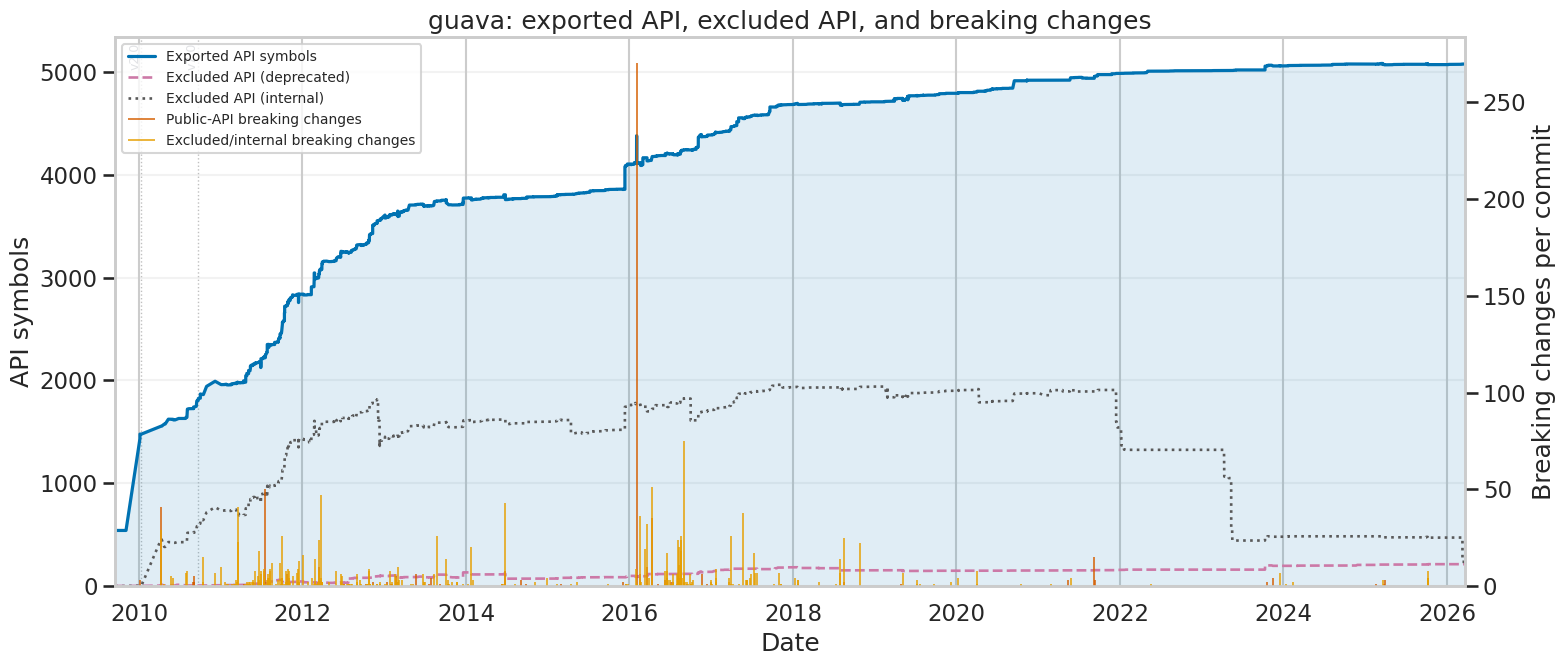

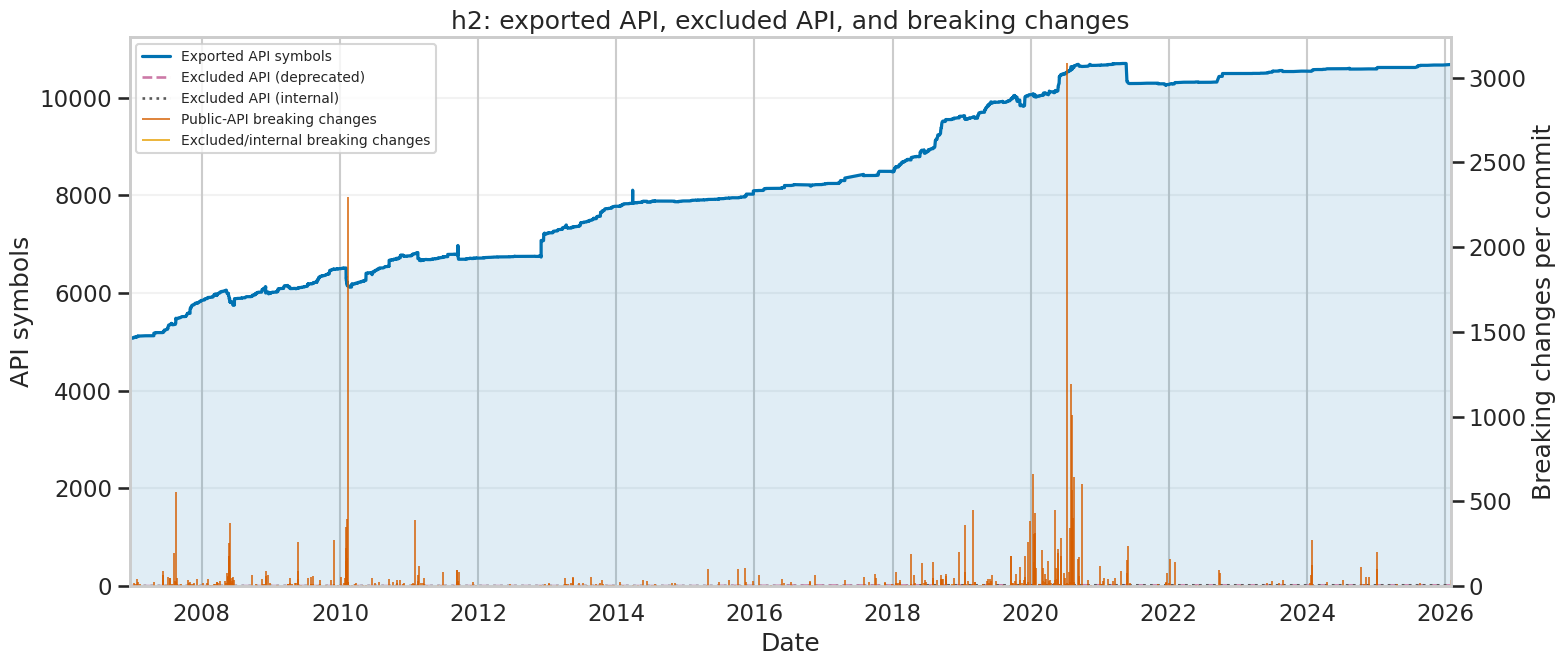

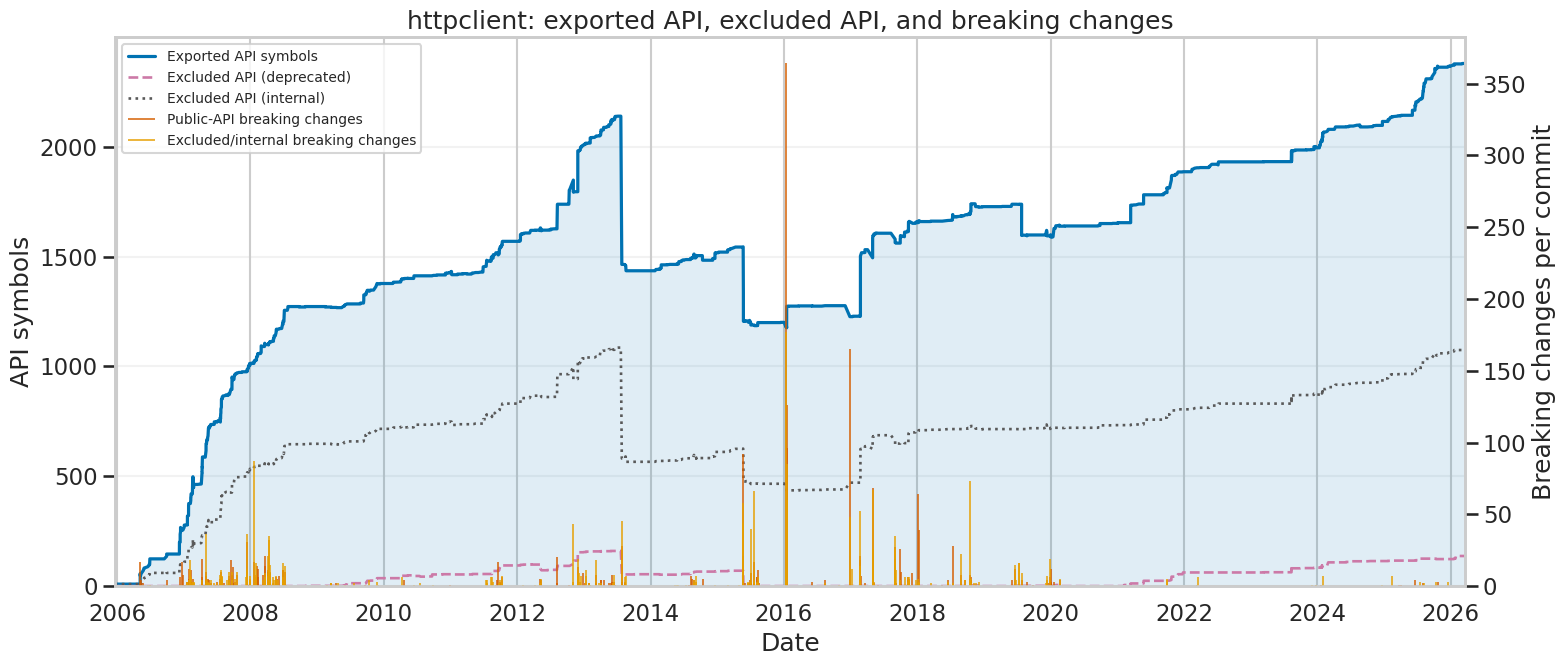

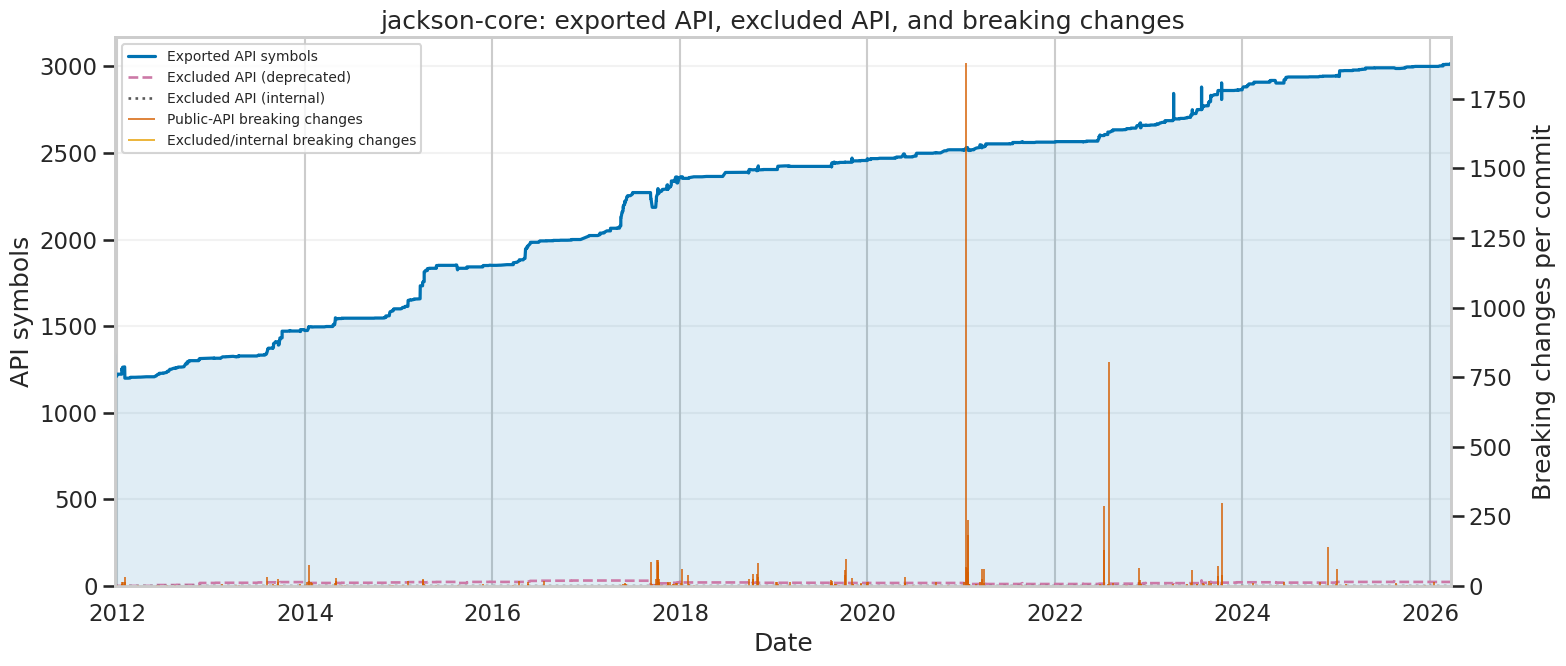

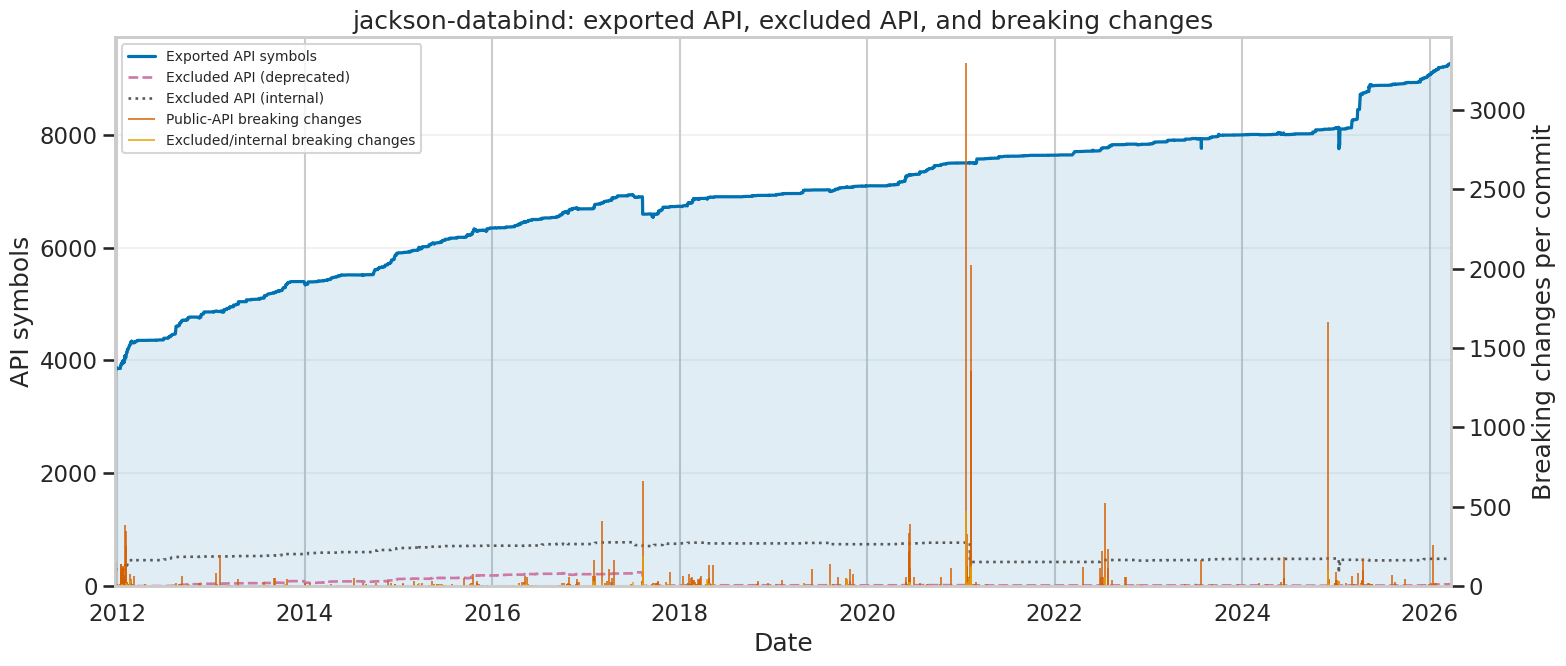

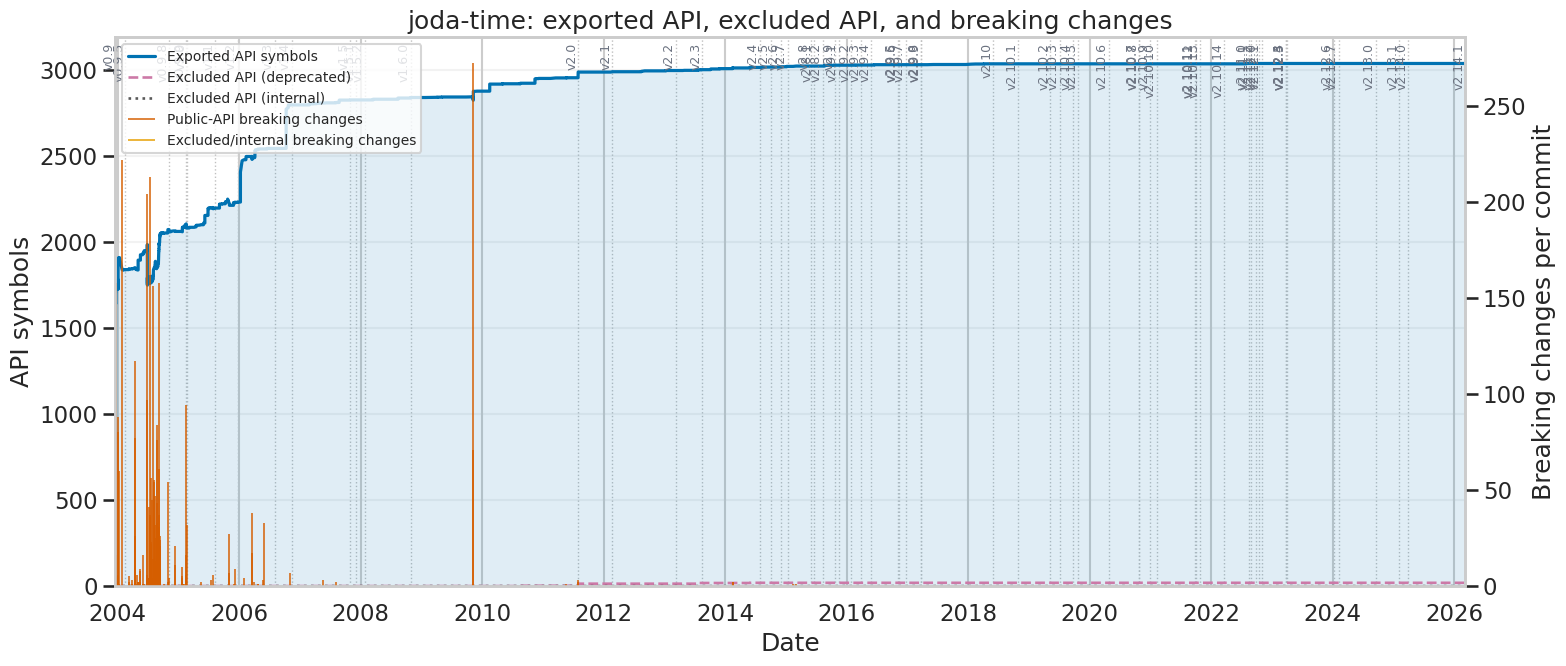

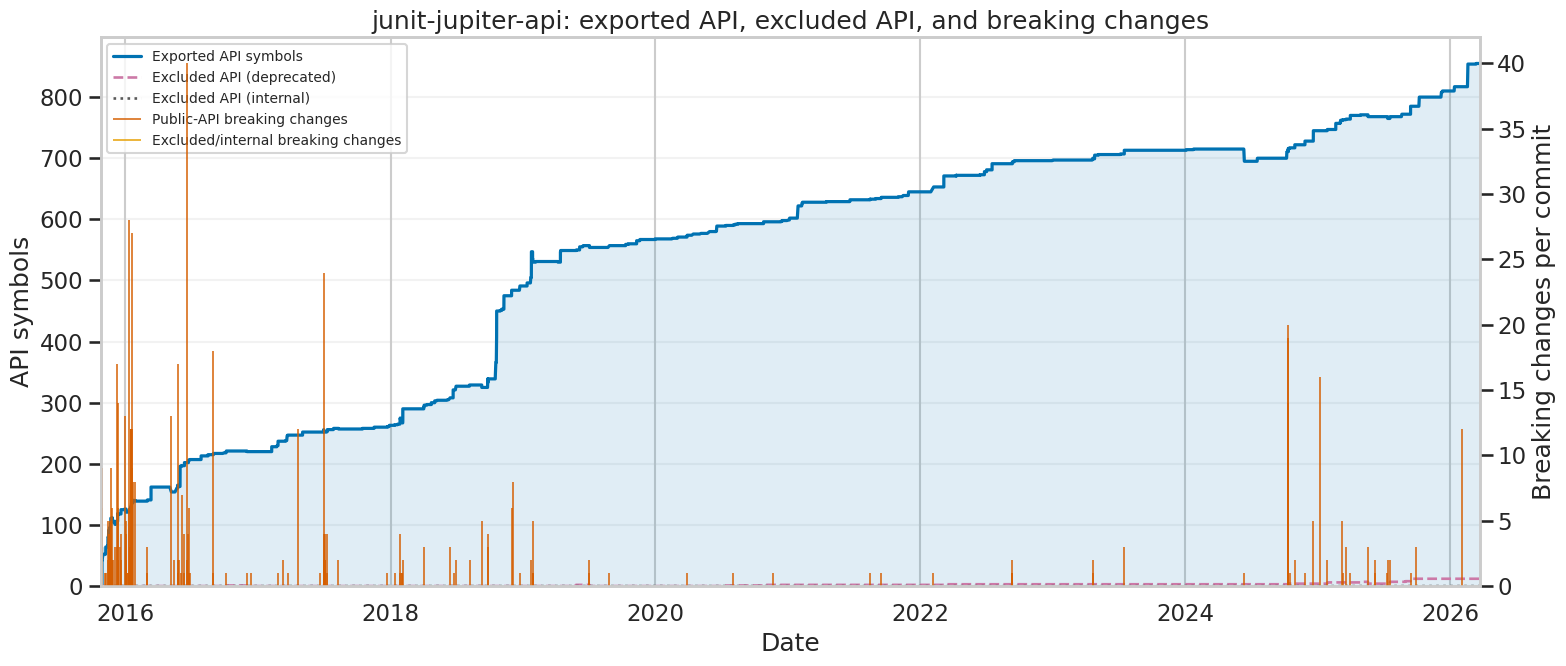

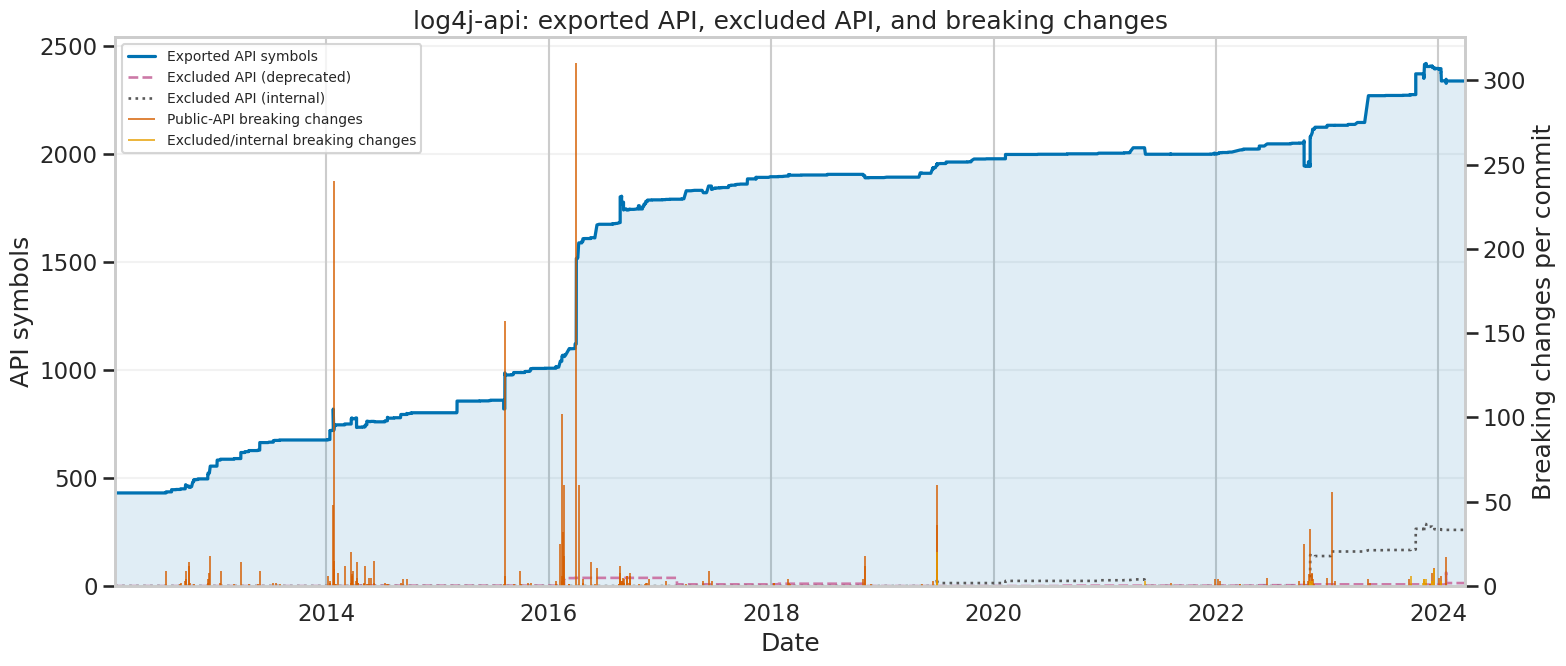

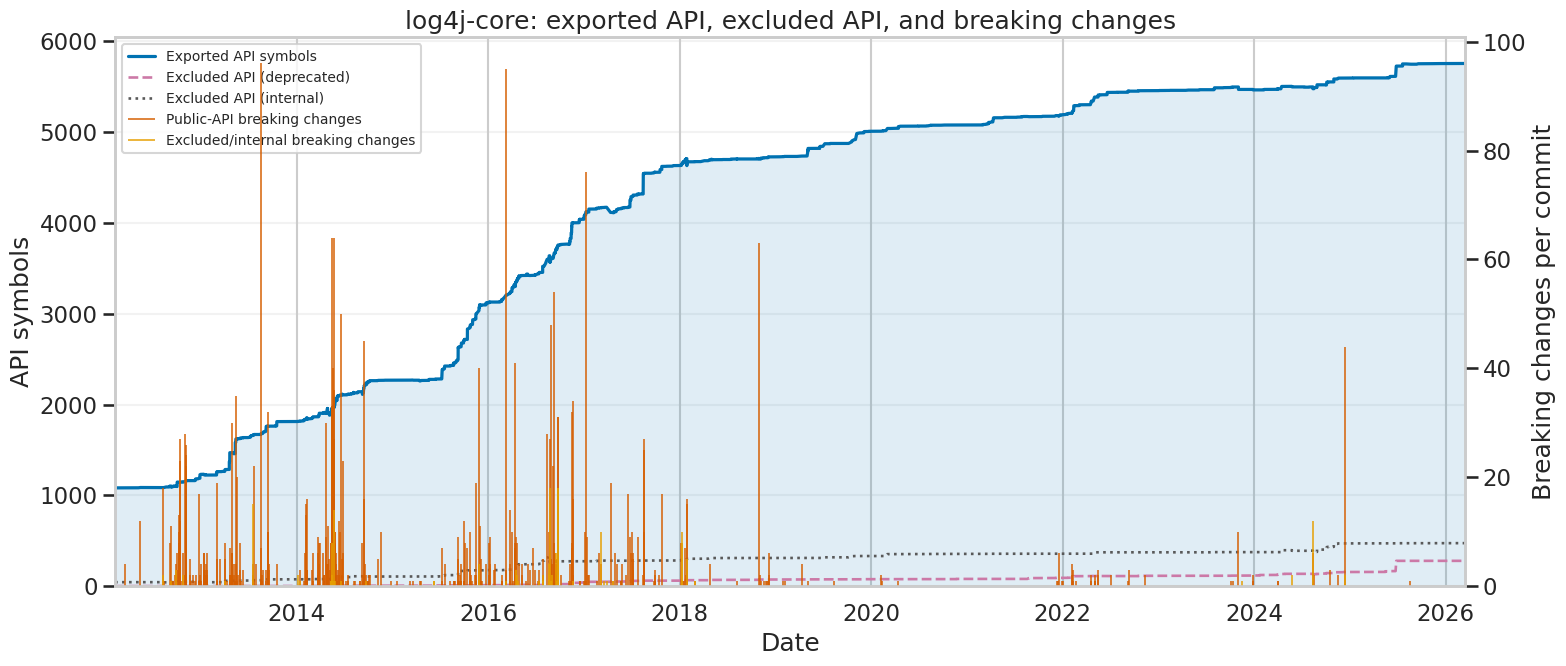

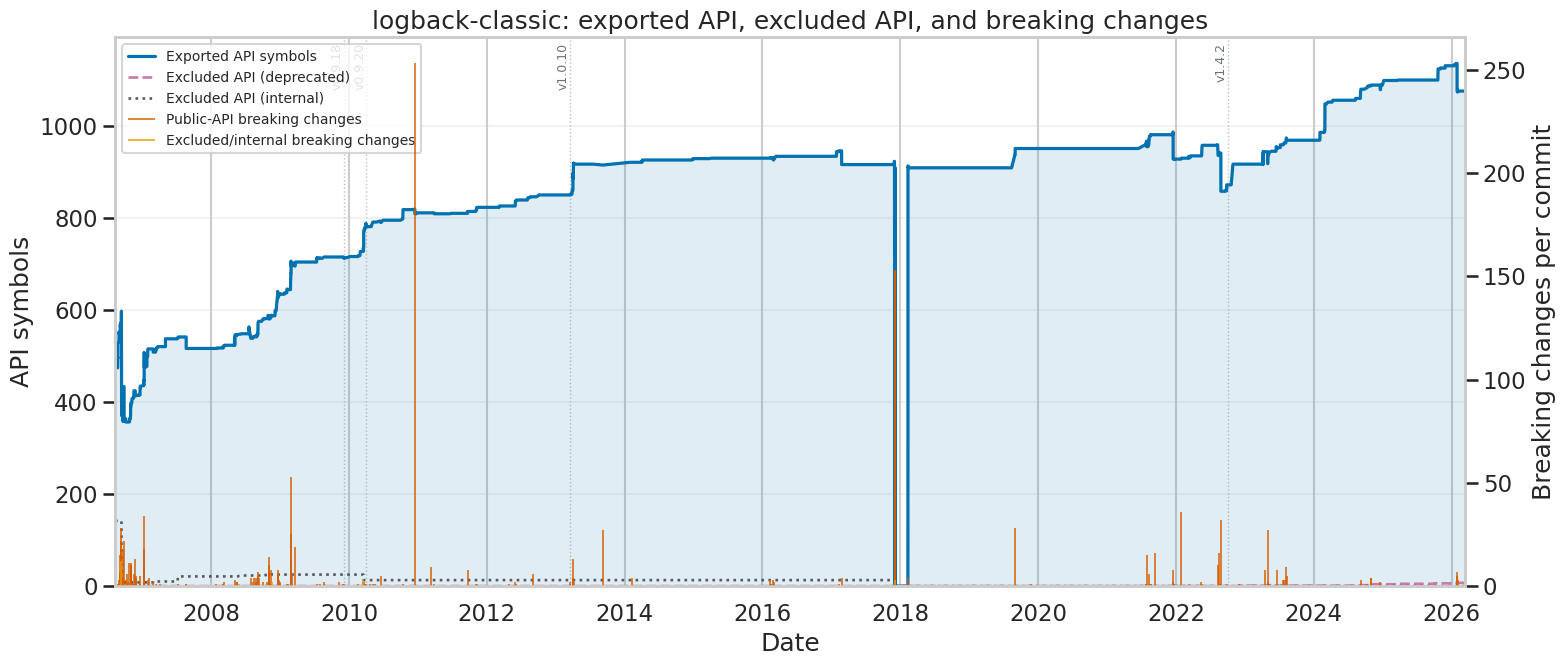

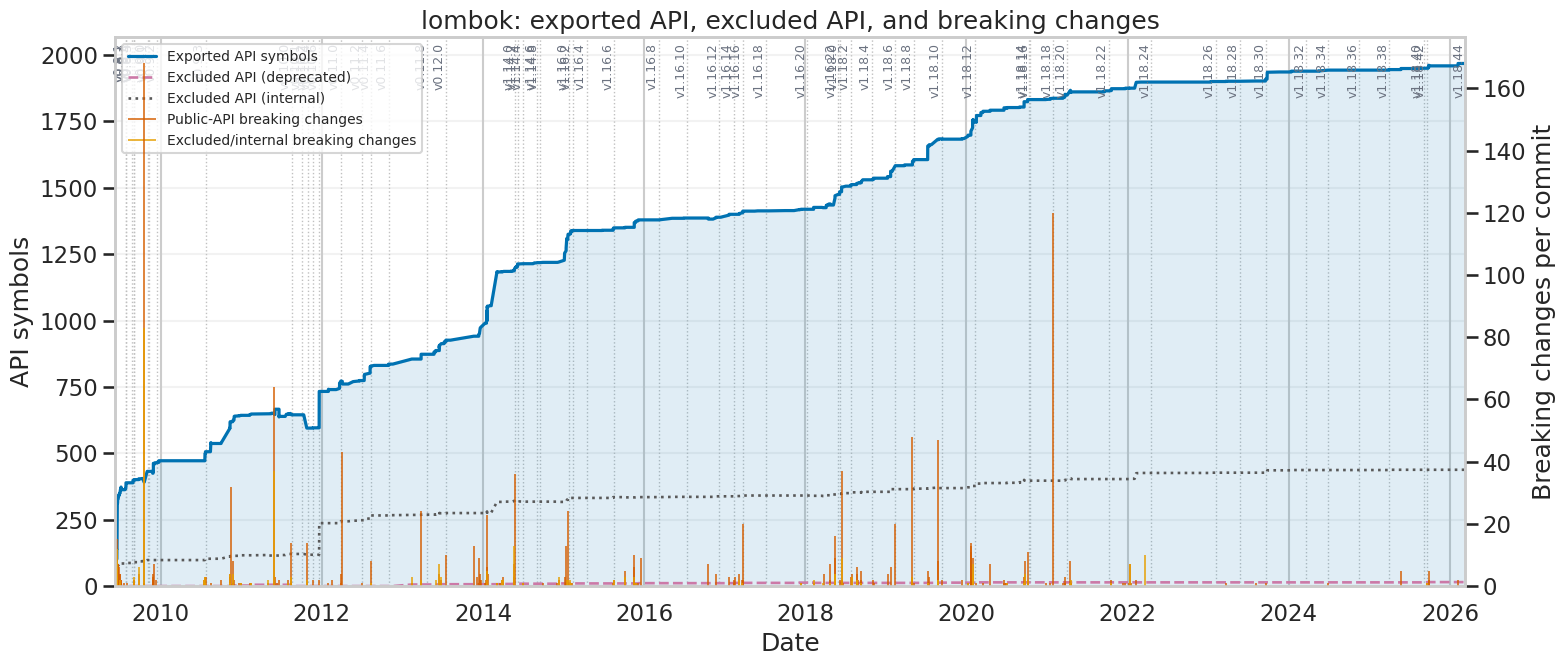

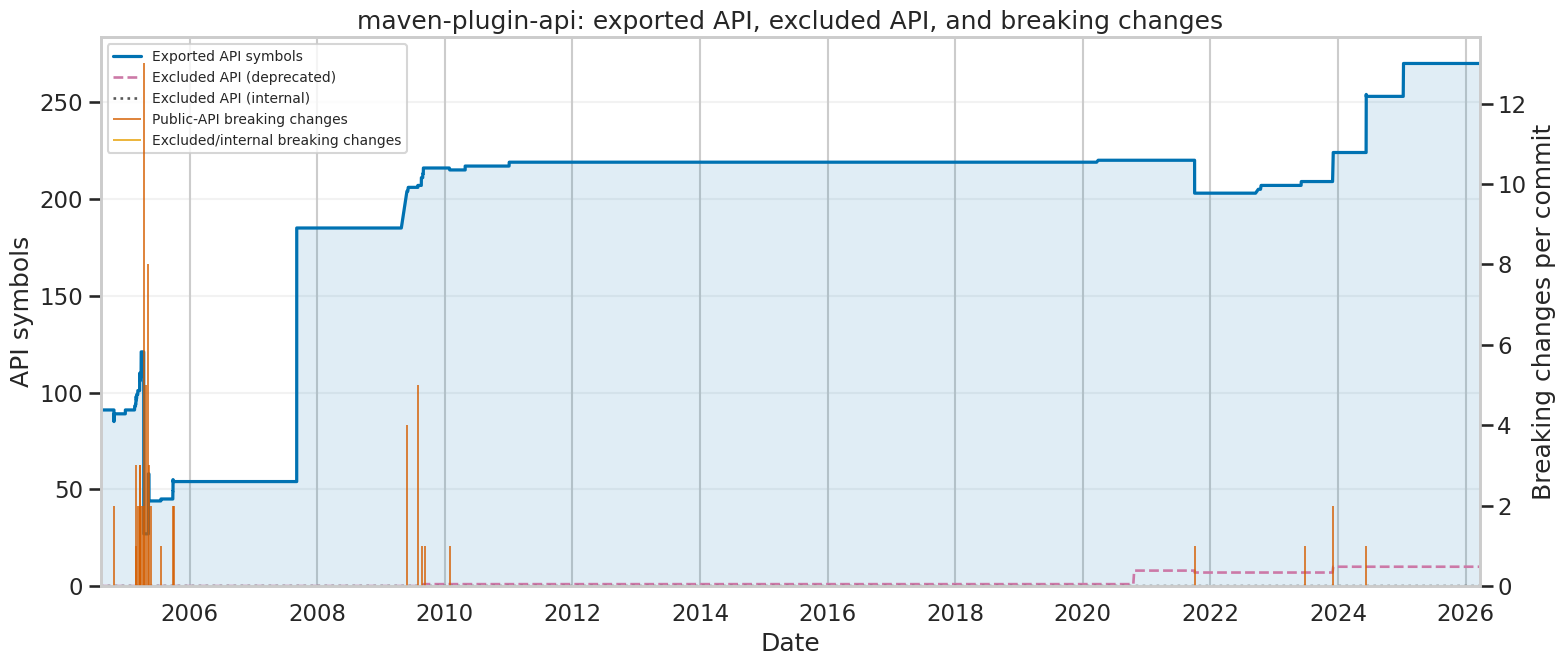

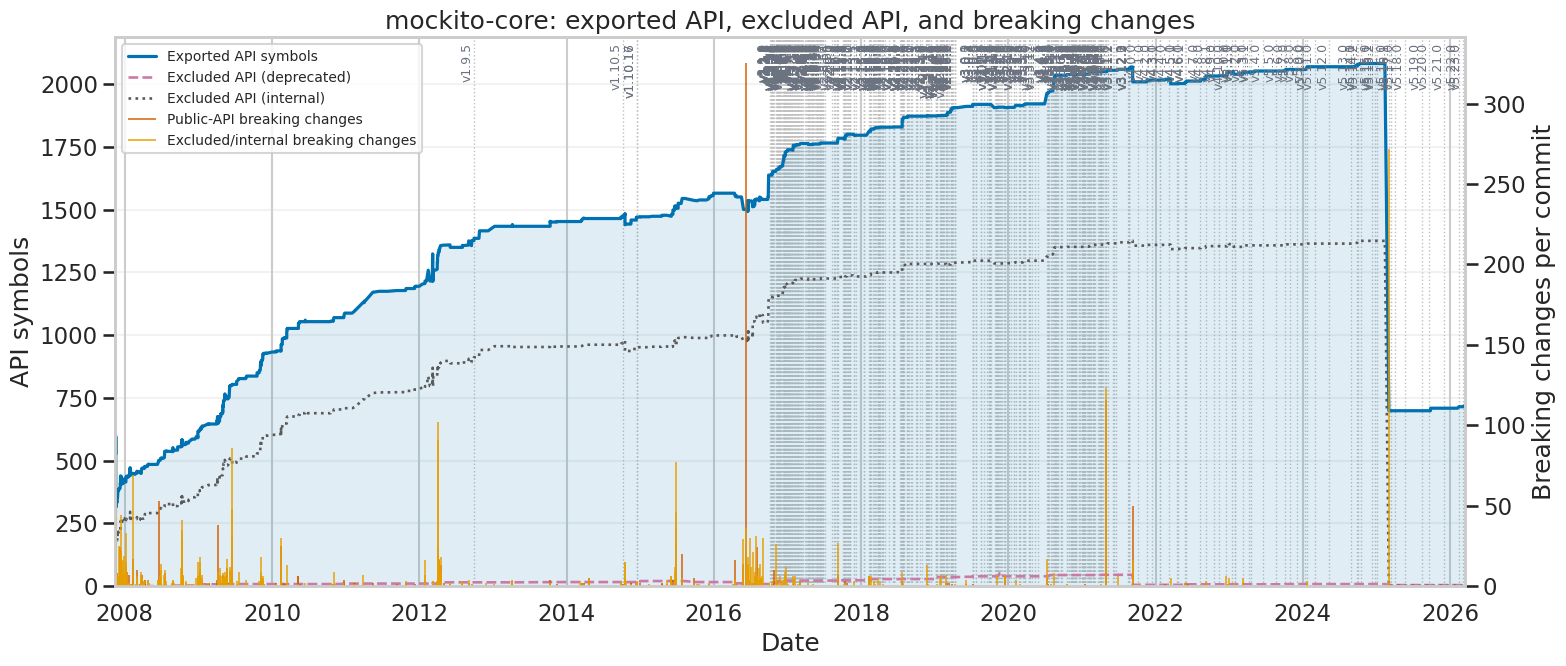

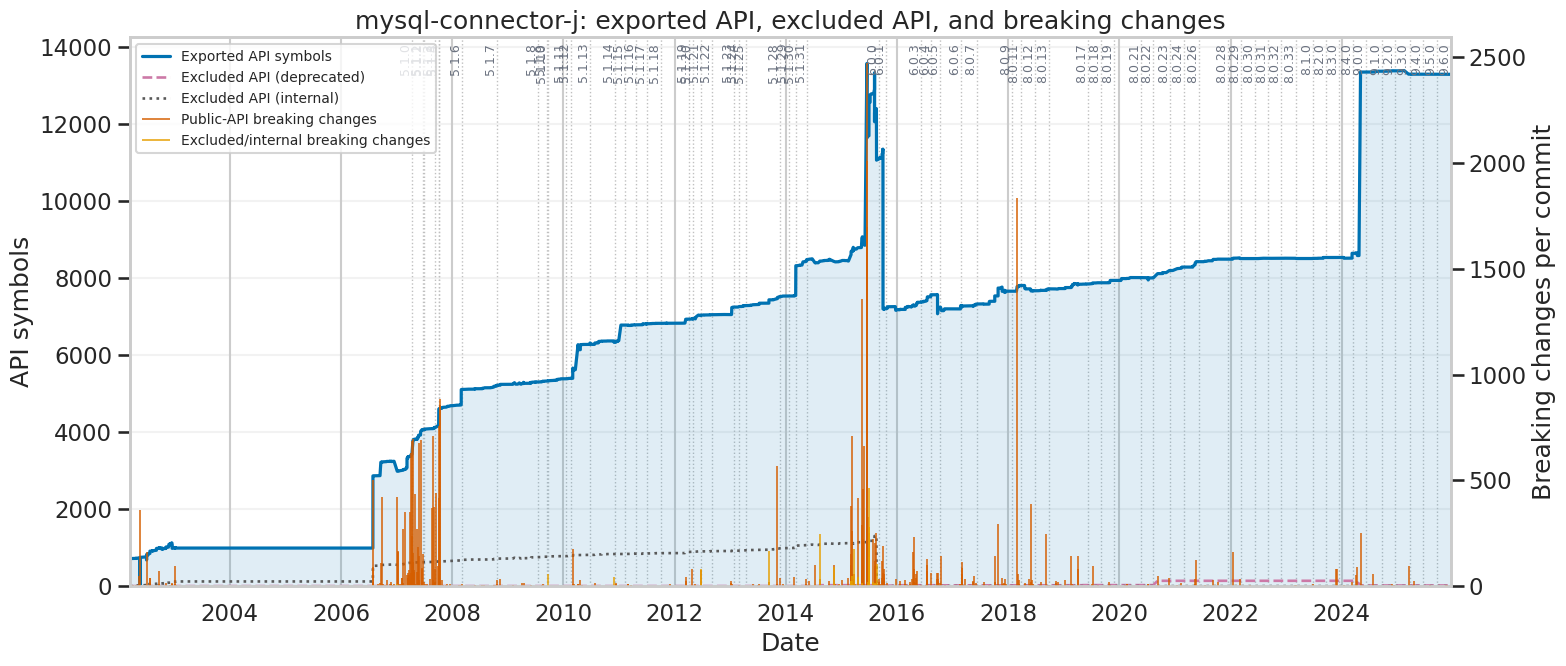

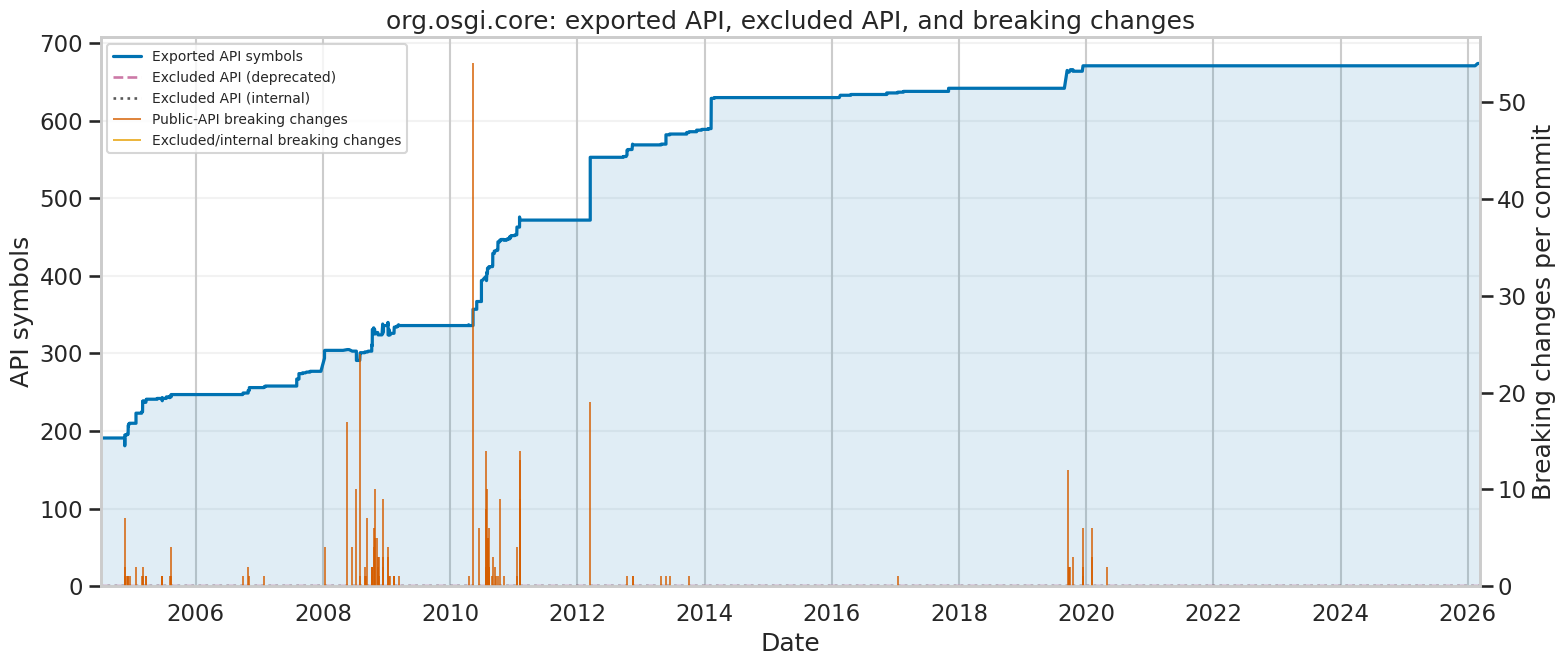

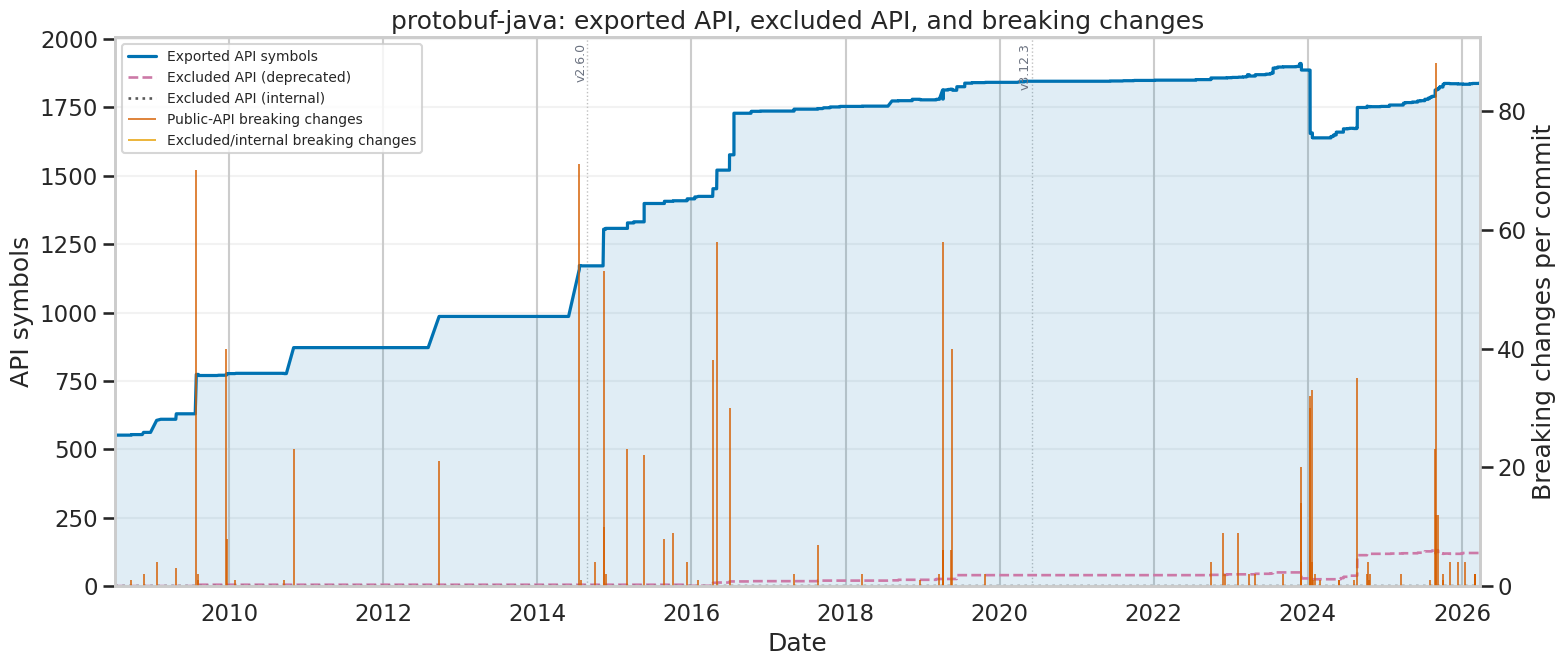

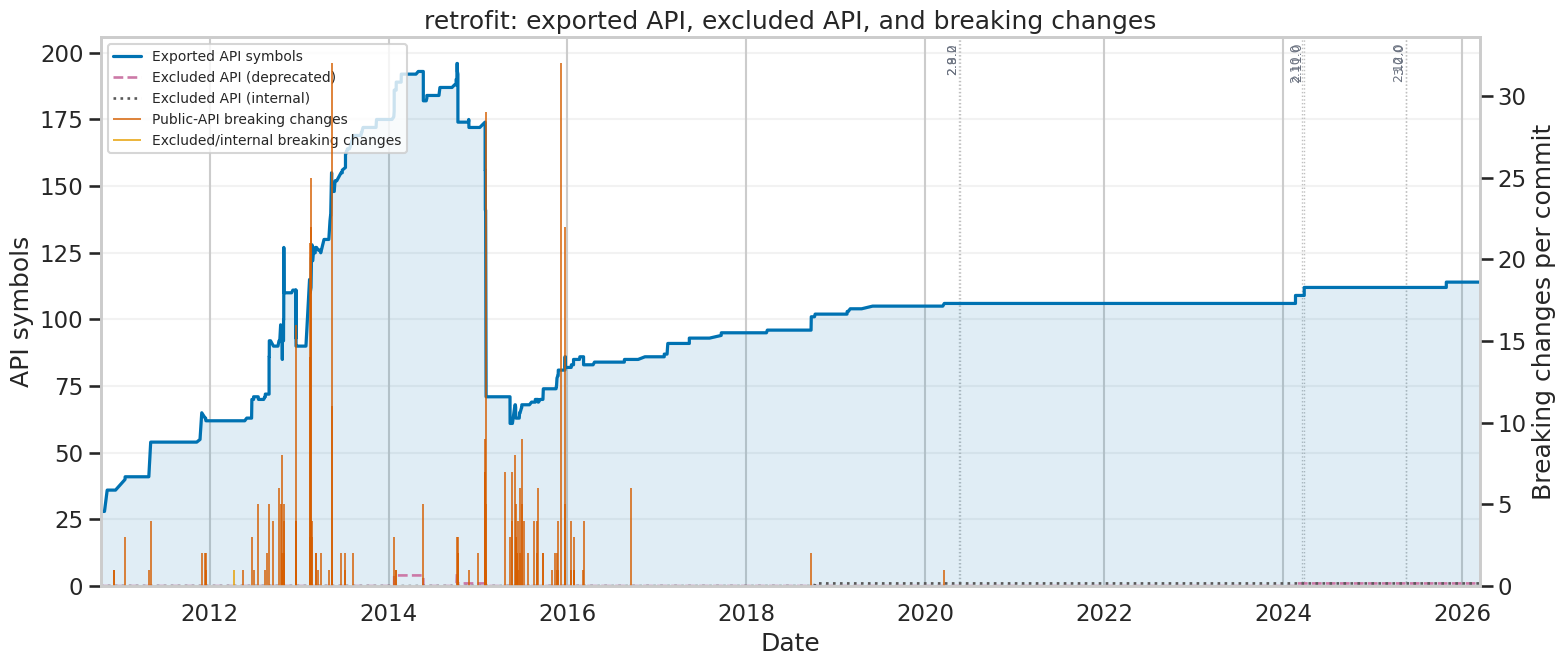

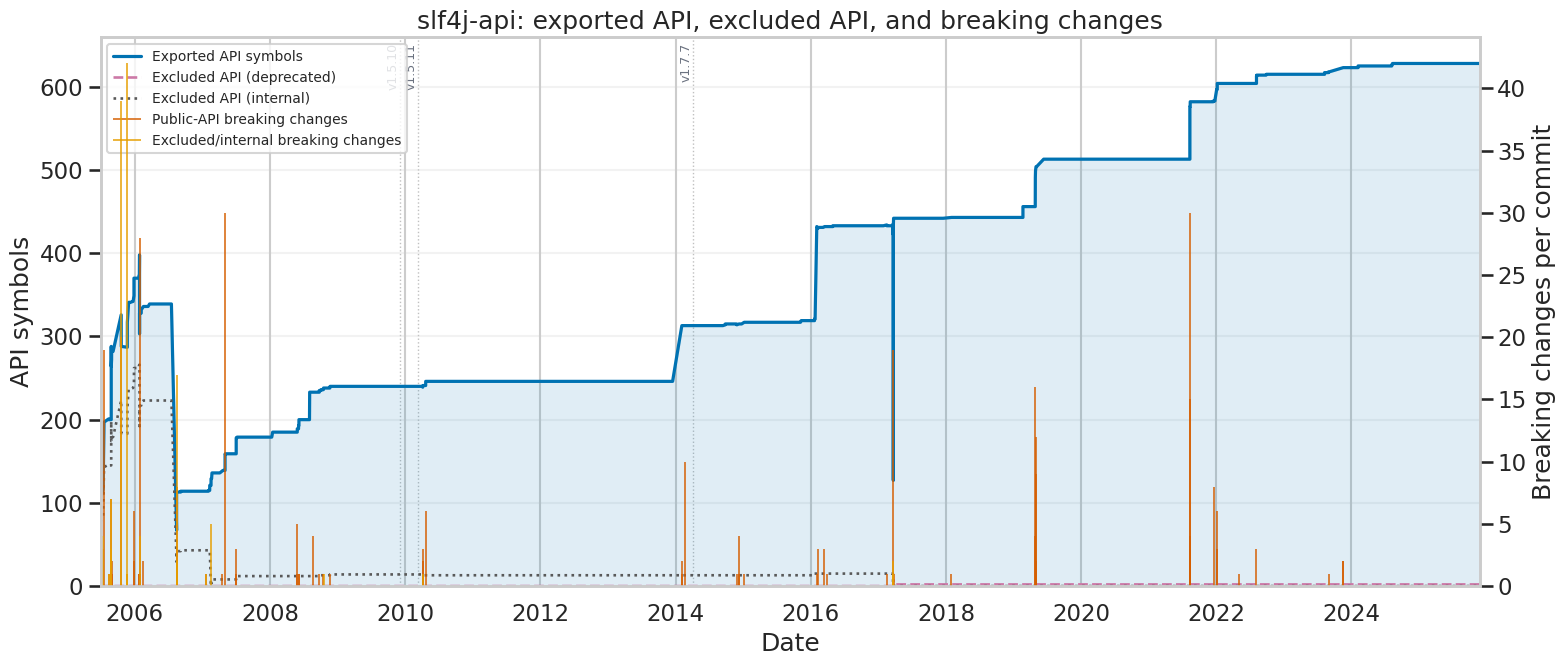

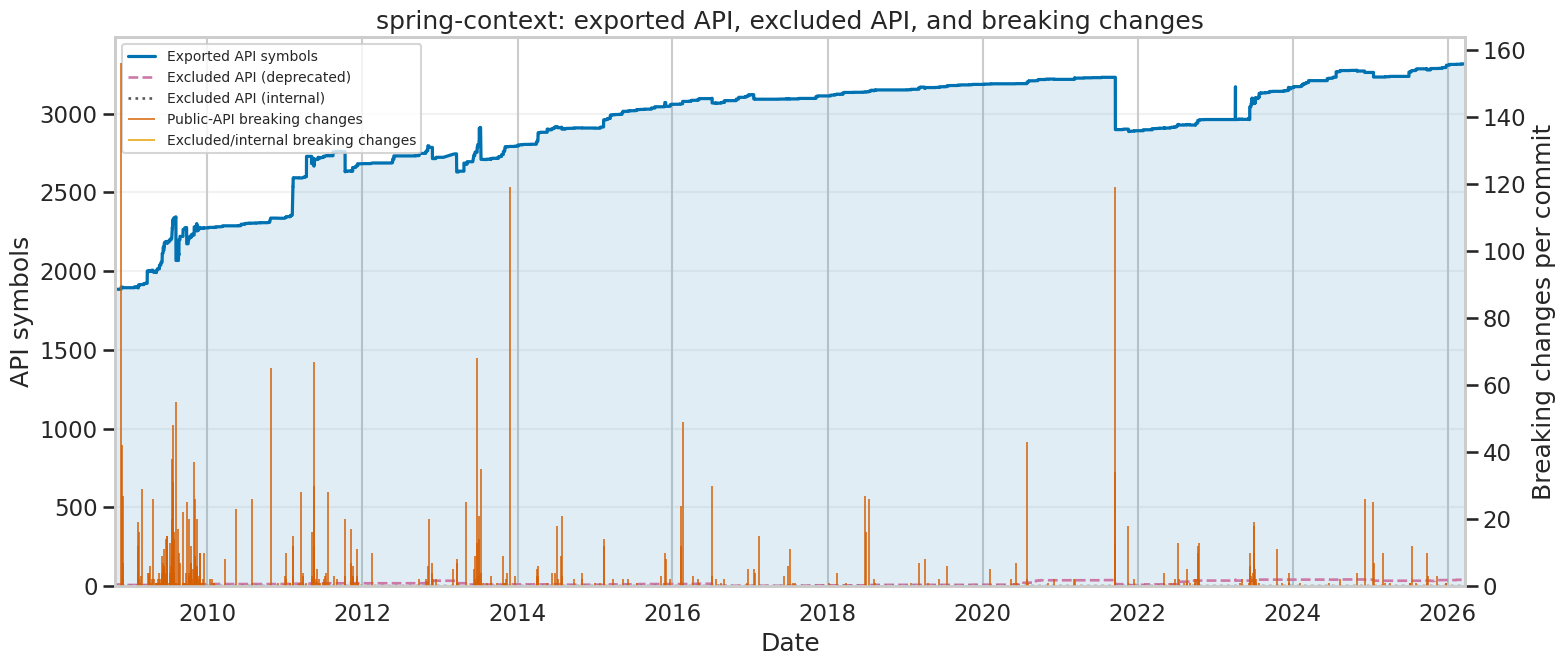

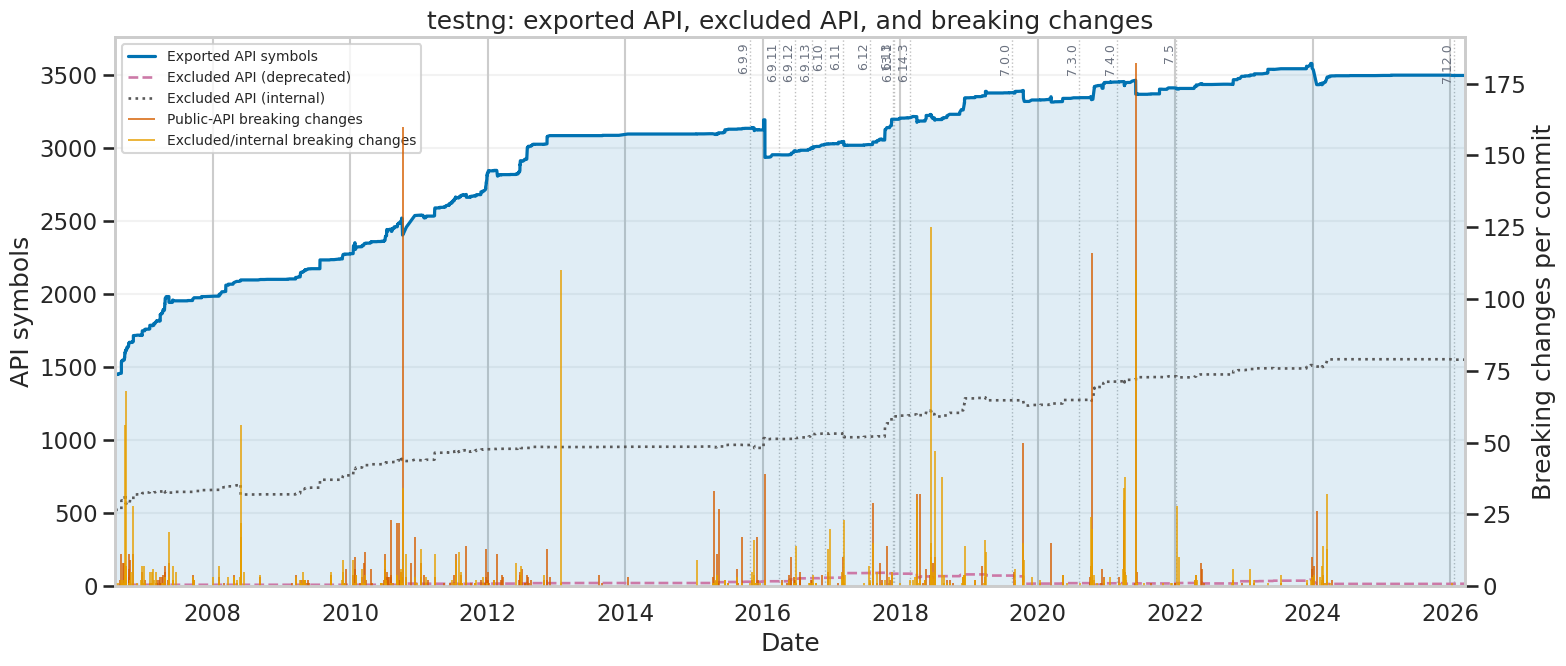

In [14]:
import matplotlib.dates as mdates

API_LINE_COLOR = "#0072B2"
DEPRECATED_LINE_COLOR = "#CC79A7"
INTERNAL_LINE_COLOR = "#595959"
PUBLIC_BREAK_COLOR = "#D55E00"
EXCLUDED_BREAK_COLOR = "#E69F00"

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

library_order = sorted(commits_df["library"].dropna().unique())

for lib in library_order:
    lib_df = commits_df.loc[commits_df["library"] == lib].copy()
    lib_df = lib_df.sort_values(["date_utc", "commit_sha"]).reset_index(drop=True)
    has_api = lib_df["all_api_symbols_count"] > 0
    start_idx = int(has_api.idxmax()) if has_api.any() else 0
    plot_df = lib_df.loc[start_idx:].copy()

    if plot_df.empty:
        continue

    release_mask = plot_df["tag"].fillna("").astype(str).str.match(
        r"^v?\d+(?:\.\d+){0,2}$"
    )
    release_df = plot_df.loc[release_mask, ["date_utc", "tag"]].drop_duplicates("tag")

    fig, ax1 = plt.subplots(figsize=(16, 7))

    ax1.plot(
        plot_df["date_utc"],
        plot_df["exported_symbols_count"],
        color=API_LINE_COLOR,
        linewidth=2.3,
        label="Exported API symbols",
    )
    ax1.plot(
        plot_df["date_utc"],
        plot_df["deprecated_count"],
        color=DEPRECATED_LINE_COLOR,
        linewidth=1.9,
        linestyle="--",
        label="Excluded API (deprecated)",
    )
    ax1.plot(
        plot_df["date_utc"],
        plot_df["internal_count"],
        color=INTERNAL_LINE_COLOR,
        linewidth=1.9,
        linestyle=":",
        label="Excluded API (internal)",
    )
    ax1.fill_between(
        plot_df["date_utc"],
        0,
        plot_df["exported_symbols_count"],
        color=API_LINE_COLOR,
        alpha=0.12,
    )
    ax1.set_xlabel("Date")
    ax1.set_ylabel("API symbols")
    ax1.set_title(f"{lib}: exported API, excluded API, and breaking changes")
    ax1.xaxis.set_major_locator(mdates.YearLocator(base=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.grid(axis="y", alpha=0.25)
    ax1.set_xlim(plot_df["date_utc"].min(), plot_df["date_utc"].max())
    ax1.set_ylim(bottom=0)
    ax1.margins(x=0, y=0)

    ax2 = ax1.twinx()
    public_breaks = plot_df.loc[plot_df["api_breaking_changes_count"] > 0]
    excluded_breaks = plot_df.loc[plot_df["excluded_breaking_changes_count"] > 0]
    ax2.vlines(
        public_breaks["date_utc"],
        0,
        public_breaks["api_breaking_changes_count"],
        color=PUBLIC_BREAK_COLOR,
        alpha=0.9,
        linewidth=1.2,
        label="Public-API breaking changes",
    )
    ax2.vlines(
        excluded_breaks["date_utc"],
        0,
        excluded_breaks["excluded_breaking_changes_count"],
        color=EXCLUDED_BREAK_COLOR,
        alpha=0.9,
        linewidth=1.2,
        label="Excluded/internal breaking changes",
    )
    ax2.set_ylabel("Breaking changes per commit")
    ax2.set_ylim(bottom=0)
    ax2.margins(x=0, y=0)
    ax2.grid(False)

    if not release_df.empty:
        for row in release_df.itertuples(index=False):
            ax1.axvline(row.date_utc, color="#c0c0c0", linestyle=":", linewidth=1.0, zorder=0)
            ax1.text(
                row.date_utc,
                0.99,
                row.tag,
                rotation=90,
                ha="right",
                va="top",
                fontsize=9,
                color="#6b7280",
                transform=ax1.get_xaxis_transform(),
            )

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper left",
        frameon=True,
        fontsize=10,
    )

    plt.tight_layout()
    figure_path = FIGURE_DIR / f"{lib}_api_excluded_breaking_changes.pdf"
    fig.savefig(figure_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
